# Predicting Contractor Total Bids for Public Construction Projects

## Project Overview

**Objective:** Build a regression model that predicts the `total_bid` a contractor will submit for a public construction project, using only pre-bid information.

**Evaluation Metric:** Root Mean Squared Logarithmic Error (RMSLE) — penalizes under-predictions more than over-predictions and is scale-invariant across bid sizes.

**Approach:**
1. Exploratory Data Analysis (EDA) on both job-level and pay-item-level data
2. Feature engineering — aggregate raw pay-item data into job-level predictors
3. Linear Regression as baseline model
4. Ridge Regression for regularized improvement
5. Evaluate with RMSLE, RMSE, MAE, and R² metrics
6. Generate final `submission.csv` on the held-out test set

**Key Constraint:** The `amount` column (unit price per pay item) is **not available** in the test set. It represents what contractors actually bid per line item, so using it would be data leakage. We must predict `total_bid` without it.

## 1. Imports and Setup

In [ ]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Third-party — data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_squared_log_error
)
from sklearn.impute import SimpleImputer

# Category encoders for target encoding
import category_encoders as ce

# Configure plotting
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.facecolor'] = '#ffffff'

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Data Loading

We have multiple data files:
- **`raw_train.csv`** — Pay-item level training data (~832K rows). Each row is one line item in a contractor's bid. Contains `amount` (unit price) and `total_bid`.
- **`train_summary.csv`** — Job-level training data (~10.6K rows). Each row is one contractor–job pair with the `total_bid`.
- **`raw_test.csv`** — Pay-item level test data (~120K rows). Does **not** contain `amount` or `total_bid`.
- **`test.csv`** — Job-level test data (1,447 rows). The row_ids we need to predict for.

**Assumption:** Since evaluation happens at the contractor–job level, we'll primarily work with `train_summary.csv` but engineer features by aggregating `raw_train.csv`.

In [ ]:
# Load all datasets
# train_summary = pd.read_csv('./train_summary.csv')
# raw_train = pd.read_csv('./raw_train.csv')
# raw_test = pd.read_csv('./raw_test.csv')
# test = pd.read_csv('./test.csv')
# sample_sub = pd.read_csv('./sample_submission.csv')

# Wends:
train_summary = pd.read_csv('./data/train_summary.csv')
raw_train = pd.read_csv('./data/raw_train.csv')
raw_test = pd.read_csv('./data/raw_test.csv')
test = pd.read_csv('./data/test.csv')
sample_sub = pd.read_csv('./data/sample_submission.csv')


print(f"train_summary:  {train_summary.shape}")
print(f"raw_train:      {raw_train.shape}")
print(f"raw_test:       {raw_test.shape}")
print(f"test:           {test.shape}")
print(f"sample_sub:     {sample_sub.shape}")

train_summary:  (10620, 6)
raw_train:      (832056, 15)
raw_test:       (120305, 13)
test:           (1447, 6)
sample_sub:     (1447, 2)


### 2.1 Quick Look at Each Dataset

Let's inspect the structure and first few rows of each file so we understand what we're working with.

In [ ]:
print("=== train_summary (job-level, what we train on) ===")
display(train_summary.head())
print(f"\nColumns: {list(train_summary.columns)}")
print(f"Shape: {train_summary.shape}")

=== train_summary (job-level, what we train on) ===


,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL
3,JOB_000002,CON_000001,400514.00,2024-07-10,LOC_000012,EROSION CONTROL
4,JOB_000002,CON_000038,293475.00,2024-07-10,LOC_000012,EROSION CONTROL



Columns: ['job_id', 'contractor_id', 'total_bid', 'bid_date', 'primary_location', 'job_category_description']
Shape: (10620, 6)


In [ ]:
print("=== raw_train (pay-item level, for feature engineering) ===")
display(raw_train.head())
print(f"\nColumns: {list(raw_train.columns)}")
print(f"Shape: {raw_train.shape}")

=== raw_train (pay-item level, for feature engineering) ===


,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015
3,1.0,1.0,BRIDGE,2018-01-18,453231.70,55,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_002829,CON_000015,LOC_000091,ITEM_003537,JOB_002829__CON_000015
4,1.0,1.0,BRIDGE,2018-01-18,1513003.05,101,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_001294,CON_000015,LOC_000028,ITEM_003537,JOB_001294__CON_000015



Columns: ['quantity', 'amount', 'job_category_description', 'bid_date', 'total_bid', 'num_pay_items', 'pay_item_description', 'unit_english_id', 'category_id', 'category_description', 'job_id', 'contractor_id', 'primary_location', 'pay_item_id', 'row_id']
Shape: (832056, 15)


In [ ]:
print("=== test (job-level, what we predict) ===")
display(test.head())
print(f"\nColumns: {list(test.columns)}")
print(f"Shape: {test.shape}")

=== test (job-level, what we predict) ===


,row_id,job_id,contractor_id,bid_date,primary_location,job_category_description
0,JOB_000008__CON_000103,JOB_000008,CON_000103,2025-03-12,LOC_000086,SIGNALIZATION
1,JOB_000030__CON_000061,JOB_000030,CON_000061,2025-03-12,LOC_000061,STRIPING/PAVEMENT MARKING
2,JOB_000030__CON_000217,JOB_000030,CON_000217,2025-03-12,LOC_000061,STRIPING/PAVEMENT MARKING
3,JOB_000045__CON_000037,JOB_000045,CON_000037,2025-10-08,LOC_000062,BRIDGE
4,JOB_000045__CON_000122,JOB_000045,CON_000122,2025-10-08,LOC_000062,BRIDGE



Columns: ['row_id', 'job_id', 'contractor_id', 'bid_date', 'primary_location', 'job_category_description']
Shape: (1447, 6)


In [ ]:
print("=== raw_test (pay-item level, for test feature engineering) ===")
display(raw_test.head())
print(f"\nColumns: {list(raw_test.columns)}")
print(f"Shape: {raw_test.shape}")
print(f"\nNote: 'amount' column is MISSING from raw_test — confirms we cannot use it as a feature.")

=== raw_test (pay-item level, for test feature engineering) ===


,quantity,job_category_description,bid_date,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,CLEARING,2025-01-15,21,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002548,CON_000037,LOC_000062,ITEM_003580,JOB_002548__CON_000037
1,1.0,CLEARING,2025-01-15,21,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_002548,CON_000037,LOC_000062,ITEM_003537,JOB_002548__CON_000037
2,1.0,ASPHALT,2025-01-15,58,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_001752,CON_000037,LOC_000062,ITEM_003537,JOB_001752__CON_000037
3,1.0,ASPHALT,2025-01-15,58,CONTRACT LIENS,$,31,ALTERNATES/BONUS/TIME,JOB_001752,CON_000037,LOC_000062,ITEM_001111,JOB_001752__CON_000037
4,1.0,CLEARING,2025-01-15,21,CONTRACT LIENS,$,31,ALTERNATES/BONUS/TIME,JOB_002548,CON_000037,LOC_000062,ITEM_001111,JOB_002548__CON_000037



Columns: ['quantity', 'job_category_description', 'bid_date', 'num_pay_items', 'pay_item_description', 'unit_english_id', 'category_id', 'category_description', 'job_id', 'contractor_id', 'primary_location', 'pay_item_id', 'row_id']
Shape: (120305, 13)

Note: 'amount' column is MISSING from raw_test — confirms we cannot use it as a feature.


In [ ]:
print("=== sample_submission ===")
display(sample_sub.head())
print(f"\nWe need to predict total_bid for {len(sample_sub)} contractor-job pairs.")

=== sample_submission ===


,row_id,total_bid
0,JOB_000008__CON_000103,1000000.0
1,JOB_000030__CON_000061,1000000.0
2,JOB_000030__CON_000217,1000000.0
3,JOB_000045__CON_000037,1000000.0
4,JOB_000045__CON_000122,1000000.0



We need to predict total_bid for 1447 contractor-job pairs.


### 2.2 Data Cleaning on some tables

In [ ]:
raw_train.isnull().sum()

quantity                    0
amount                      0
job_category_description    0
bid_date                    0
total_bid                   0
num_pay_items               0
pay_item_description        0
unit_english_id             2
category_id                 0
category_description        0
job_id                      0
contractor_id               0
primary_location            0
pay_item_id                 0
row_id                      0
dtype: int64

Decision: We will not remove the 2 rows that contains the null values in the `raw_train` dataset, as they only account for a very small percentage of the data and removing them would not significantly impact performances. And the aggregations later will already handle these by ignoring nulls in the sum and mean calculations.

In [ ]:
raw_test.isnull().sum()

quantity                    0
job_category_description    0
bid_date                    0
num_pay_items               0
pay_item_description        0
unit_english_id             0
category_id                 0
category_description        0
job_id                      0
contractor_id               0
primary_location            0
pay_item_id                 0
row_id                      0
dtype: int64

In [ ]:
train_summary.isnull().sum()

job_id                      0
contractor_id               0
total_bid                   0
bid_date                    0
primary_location            0
job_category_description    0
bid_year                    0
bid_month                   0
bid_quarter                 0
row_id                      0
dtype: int64

No other data cleaning needed

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Analysis: `total_bid`

Before building any model, we need to deeply understand our target variable. Since we're evaluated on RMSLE, the distribution of `total_bid` matters a lot — RMSLE essentially measures error in log-space, so a log-normal target is ideal.

In [ ]:
# Basic statistics of total_bid
print("=== total_bid Statistics ===")
print(train_summary['total_bid'].describe())
print(f"\nSkewness:  {train_summary['total_bid'].skew():.2f}")
print(f"Kurtosis:  {train_summary['total_bid'].kurtosis():.2f}")
print(f"\nMedian:    ${train_summary['total_bid'].median():,.2f}")
print(f"Mean:      ${train_summary['total_bid'].mean():,.2f}")

=== total_bid Statistics ===
count    1.062000e+04
mean     3.518911e+06
std      1.177548e+07
min      1.286500e+04
25%      6.492719e+05
50%      1.498738e+06
75%      3.285946e+06
max      4.089809e+08
Name: total_bid, dtype: float64

Skewness:  21.12
Kurtosis:  598.19

Median:    $1,498,737.95
Mean:      $3,518,910.94


**Interpretation:** If the mean is significantly larger than the median, the distribution is right-skewed — meaning most bids are moderate but there are some very large bids pulling the mean up. This is expected in construction where project sizes vary enormously (small road repairs vs. major bridge builds).

**Why this matters for RMSLE:** RMSLE = RMSE(log(pred+1), log(actual+1)). If the data is right-skewed, taking the log transforms it closer to normal, which is exactly what RMSLE does. This confirms our evaluation metric is well-chosen for this data.

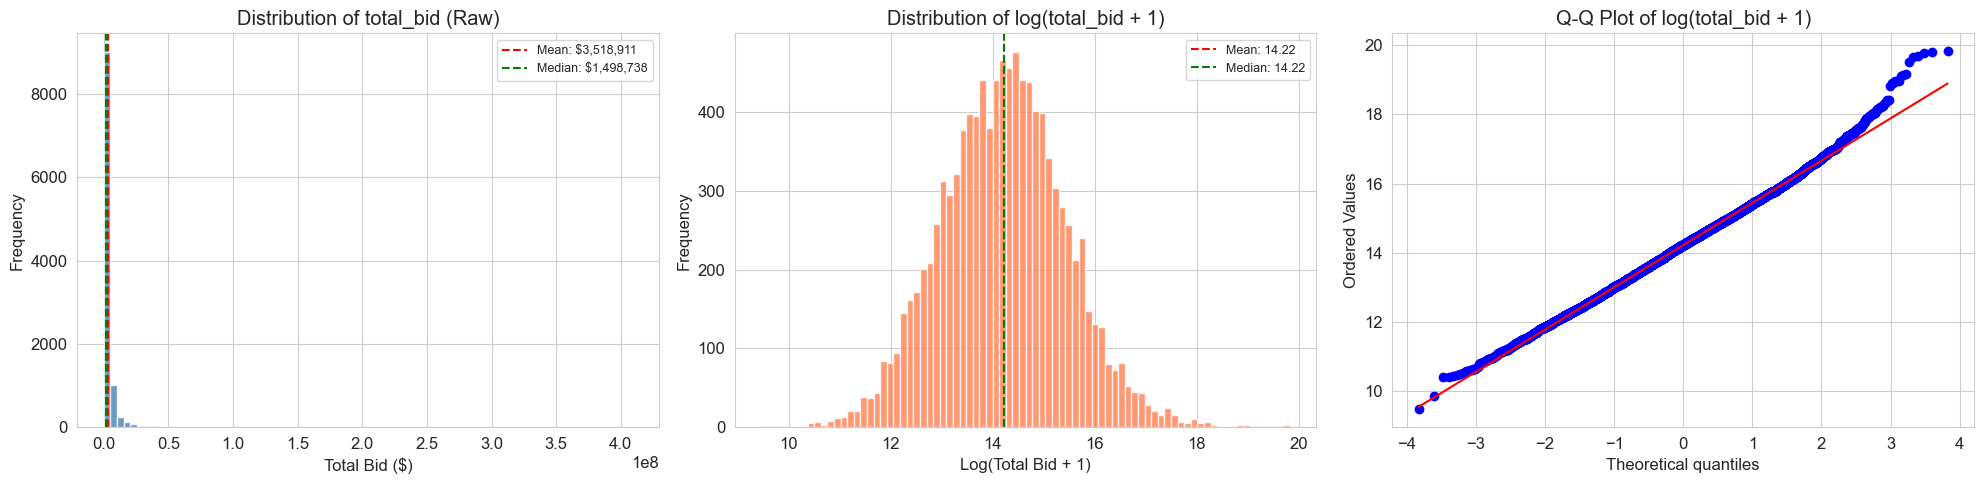

Skewness of raw total_bid:  21.12
Skewness of log(total_bid): 0.16

=> The log-transform dramatically reduces skewness, bringing it closer to normal.
=> This tells us: training on log(total_bid) and exponentiating predictions is a sound strategy.


In [ ]:
# Distribution of total_bid: raw vs log-transformed
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Raw distribution
axes[0].hist(train_summary['total_bid'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of total_bid (Raw)')
axes[0].set_xlabel('Total Bid ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_summary['total_bid'].mean(), color='red', linestyle='--', label=f"Mean: ${train_summary['total_bid'].mean():,.0f}")
axes[0].axvline(train_summary['total_bid'].median(), color='green', linestyle='--', label=f"Median: ${train_summary['total_bid'].median():,.0f}")
axes[0].legend(fontsize=9)

# Log-transformed distribution
log_bids = np.log1p(train_summary['total_bid'])
axes[1].hist(log_bids, bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of log(total_bid + 1)')
axes[1].set_xlabel('Log(Total Bid + 1)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(log_bids.mean(), color='red', linestyle='--', label=f"Mean: {log_bids.mean():.2f}")
axes[1].axvline(log_bids.median(), color='green', linestyle='--', label=f"Median: {log_bids.median():.2f}")
axes[1].legend(fontsize=9)

# QQ-plot of log-transformed
stats.probplot(log_bids, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of log(total_bid + 1)')

plt.tight_layout()
plt.show()

print(f"Skewness of raw total_bid:  {train_summary['total_bid'].skew():.2f}")
print(f"Skewness of log(total_bid): {log_bids.skew():.2f}")

Log transform will help reduce skewness and will help bring the distribution closer to normal, which is beneficial for regression models that assume normally distributed errors. It also means that our model will focus more on relative errors rather than absolute errors, which is important given the wide range of bid amounts.

### 3.2 Job Category Analysis

**Thinking:** Different construction categories (Bridge, Asphalt, Drainage, etc.) likely have vastly different bid ranges. A bridge project costs far more than a guardrail job. Let's check if `job_category_description` is a strong predictor.

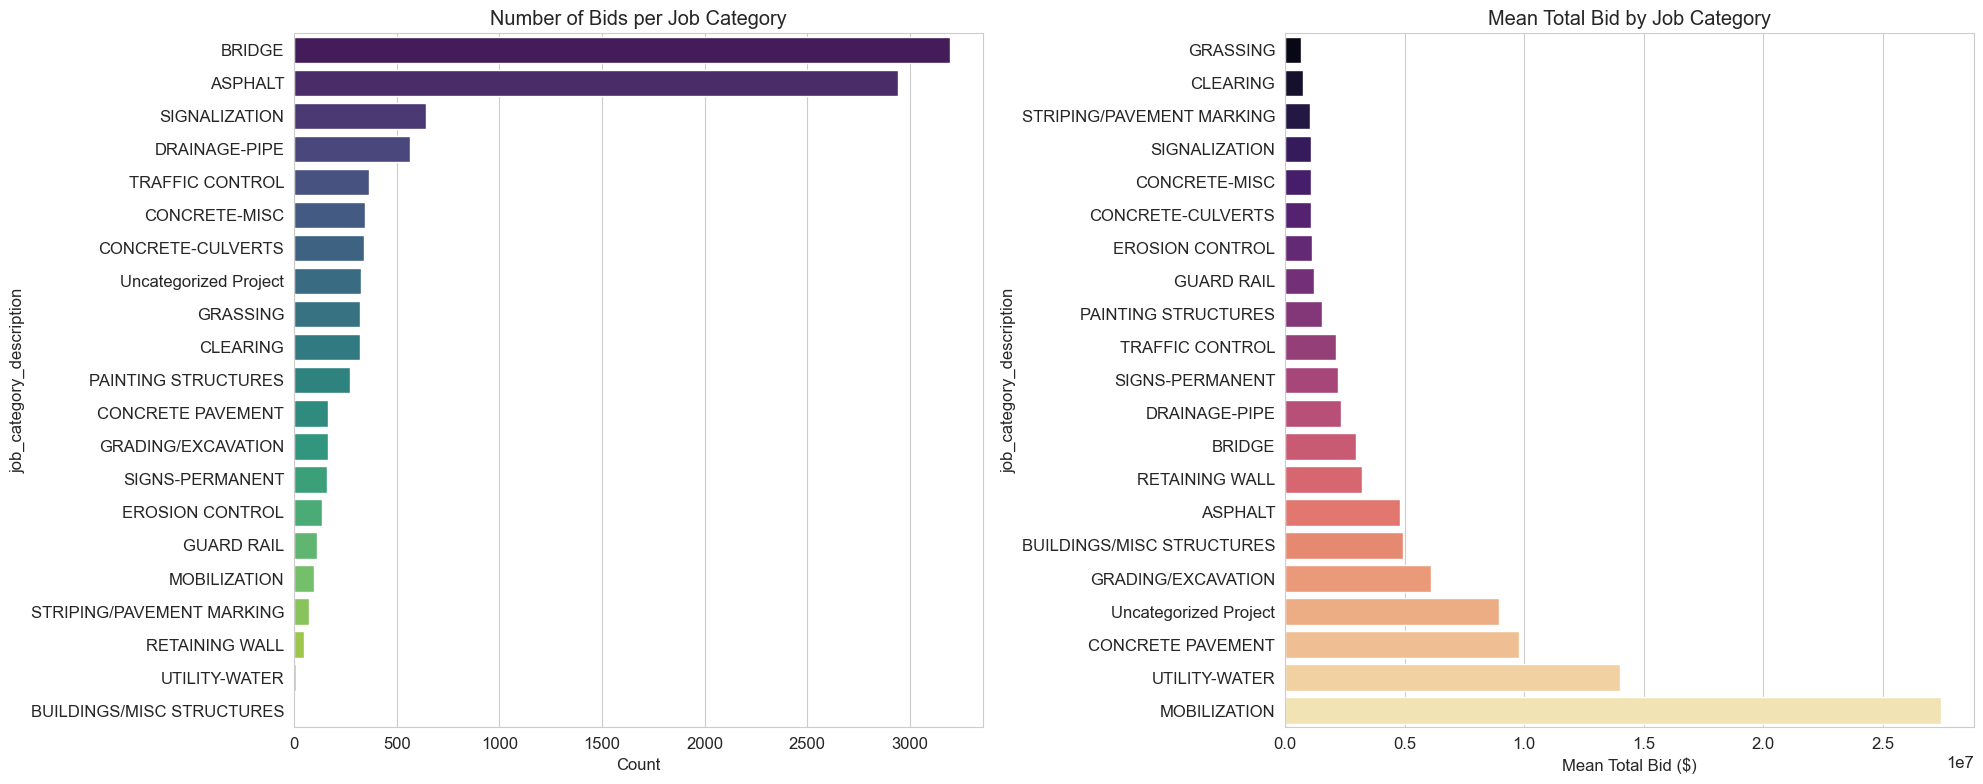

Top 5 categories by mean bid:
  GRADING/EXCAVATION: $6,112,441
  Uncategorized Project: $8,936,590
  CONCRETE PAVEMENT: $9,789,581
  UTILITY-WATER: $13,992,784
  MOBILIZATION: $27,438,030


In [ ]:
# Count of bids per job category
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Count plot
cat_counts = train_summary['job_category_description'].value_counts()
sns.barplot(y=cat_counts.index, x=cat_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Number of Bids per Job Category')
axes[0].set_xlabel('Count')

# Mean total_bid by category
cat_means = train_summary.groupby('job_category_description')['total_bid'].mean().sort_values(ascending=True)
sns.barplot(y=cat_means.index, x=cat_means.values, ax=axes[1], palette='magma')
axes[1].set_title('Mean Total Bid by Job Category')
axes[1].set_xlabel('Mean Total Bid ($)')

plt.tight_layout()
plt.show()

print("Top 5 categories by mean bid:")
for cat, val in cat_means.tail(5).items():
    print(f"  {cat}: ${val:,.0f}")

**Findings:**
- There is a **huge range** in mean bids across categories. Categories like BRIDGE and CONCRETE PAVEMENT tend to have much higher bids than CLEARING or GUARD RAIL.
- This confirms that `job_category_description` is a **strong predictor** of `total_bid`. The category essentially tells us the scale and complexity of the project.
- **Cross-check:** Higher-bid categories (Bridge, Asphalt) typically involve heavy materials, machinery, and longer durations — it makes sense they cost more.

**Assumption:** Target encoding `job_category_description` by mean `total_bid` will capture this relationship effectively for our linear models.

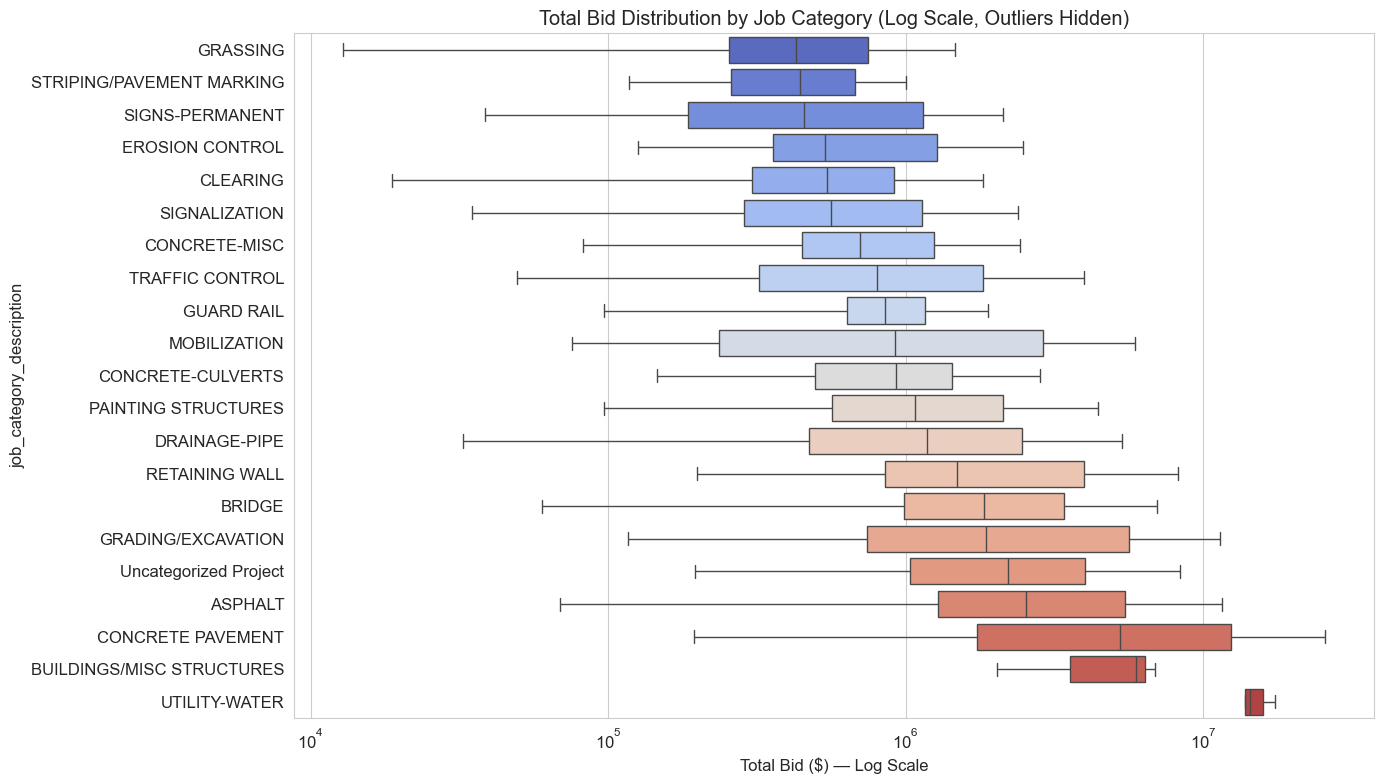

Observation: The spread (IQR) also varies by category — Bridge bids have a wider range,
meaning there's more variance in bridge project costs. Simpler categories (Grassing, Guard Rail)
have tighter distributions, making them easier to predict.


In [ ]:
# Boxplot of total_bid by job category (log scale for visibility)
fig, ax = plt.subplots(figsize=(14, 8))
order = train_summary.groupby('job_category_description')['total_bid'].median().sort_values().index
sns.boxplot(
    data=train_summary, y='job_category_description', x='total_bid',
    order=order, palette='coolwarm', ax=ax, showfliers=False
)
ax.set_xscale('log')
ax.set_title('Total Bid Distribution by Job Category (Log Scale, Outliers Hidden)')
ax.set_xlabel('Total Bid ($) — Log Scale')
plt.tight_layout()
plt.show()

print("Observation: The spread (IQR) also varies by category — Bridge bids have a wider range,")
print("meaning there's more variance in bridge project costs. Simpler categories (Grassing, Guard Rail)")
print("have tighter distributions, making them easier to predict.")

### 3.3 Primary Location Analysis

**Thinking:** Location likely correlates with bid amounts — some regions may have more expensive projects due to terrain, labor costs, or project scale. Let's check how `primary_location` relates to `total_bid`.

Number of unique locations: 93
Number of bids: 10620
Average bids per location: 114.2


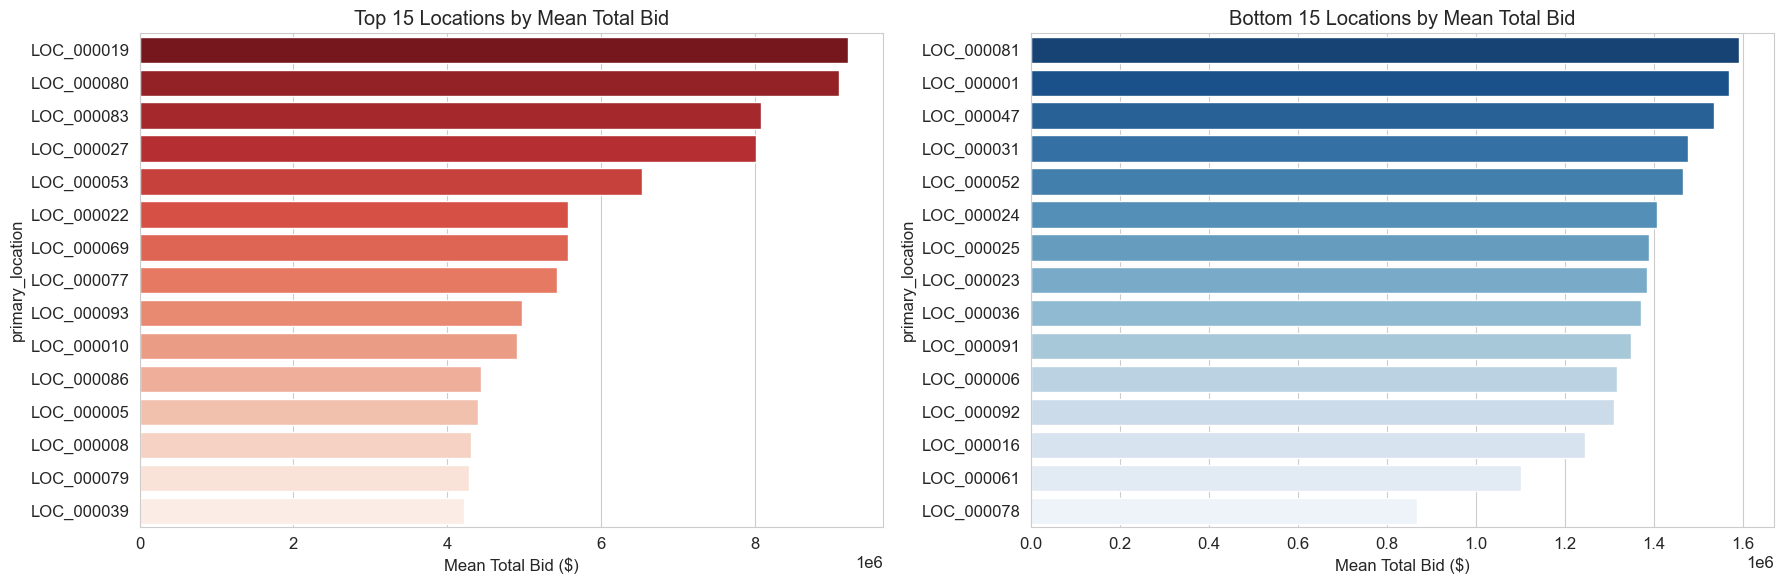


Range of location means: $868,044 to $9,209,448
=> Location is a meaningful predictor — some locations consistently have larger projects.


In [ ]:
# How many unique locations?
n_locations = train_summary['primary_location'].nunique()
print(f"Number of unique locations: {n_locations}")
print(f"Number of bids: {len(train_summary)}")
print(f"Average bids per location: {len(train_summary) / n_locations:.1f}")

# Top/bottom locations by mean bid
loc_stats = train_summary.groupby('primary_location')['total_bid'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 15 locations by mean bid
top_locs = loc_stats.head(15)
sns.barplot(y=top_locs.index, x=top_locs['mean'], ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Locations by Mean Total Bid')
axes[0].set_xlabel('Mean Total Bid ($)')

# Bottom 15 locations by mean bid
bottom_locs = loc_stats.tail(15)
sns.barplot(y=bottom_locs.index, x=bottom_locs['mean'], ax=axes[1], palette='Blues_r')
axes[1].set_title('Bottom 15 Locations by Mean Total Bid')
axes[1].set_xlabel('Mean Total Bid ($)')

plt.tight_layout()
plt.show()

print(f"\nRange of location means: ${loc_stats['mean'].min():,.0f} to ${loc_stats['mean'].max():,.0f}")

**Findings:**
- Location means range significantly, confirming that **geography matters** for bid prediction.
- Some locations likely correspond to urban/rural areas or specific project types.
- **Cross-check with job category:** Locations with high mean bids might simply host more bridge/highway projects. Let's verify this isn't just a proxy for category.

**Assumption:** We'll use target encoding for location as well, since it has many unique values (too many for one-hot encoding).

### 3.4 Contractor Bidding Patterns

**Thinking:** Different contractors may have systematic bidding strategies — some always bid high, others competitively low. A contractor's identity might encode their pricing strategy, equipment capacity, and overhead costs.

Number of unique contractors: 228

Contractor bid frequency distribution:
count     228.000000
mean       46.578947
std       126.673252
min         1.000000
25%         2.000000
50%         9.000000
75%        37.250000
max      1097.000000
Name: count, dtype: float64


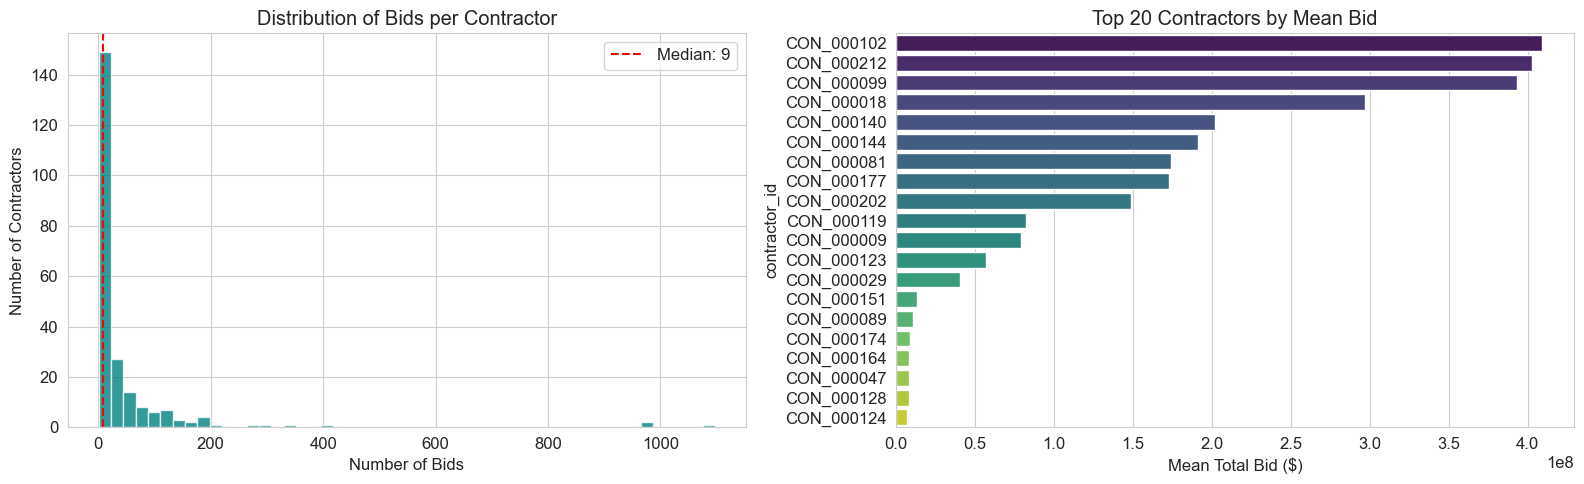


Some contractors bid on very few projects (min: 1),
while others are prolific (max: 1097).
For contractors with few bids, target encoding will smooth towards the global mean.


In [ ]:
# Contractor statistics
n_contractors = train_summary['contractor_id'].nunique()
contractor_stats = train_summary.groupby('contractor_id')['total_bid'].agg(['mean', 'median', 'count', 'std'])
contractor_stats = contractor_stats.sort_values('mean', ascending=False)

print(f"Number of unique contractors: {n_contractors}")
print(f"\nContractor bid frequency distribution:")
print(contractor_stats['count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of bids per contractor
axes[0].hist(contractor_stats['count'], bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Bids per Contractor')
axes[0].set_xlabel('Number of Bids')
axes[0].set_ylabel('Number of Contractors')
axes[0].axvline(contractor_stats['count'].median(), color='red', linestyle='--', label=f"Median: {contractor_stats['count'].median():.0f}")
axes[0].legend()

# Top 20 contractors by mean bid
top_contractors = contractor_stats.head(20)
sns.barplot(y=top_contractors.index, x=top_contractors['mean'], ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Contractors by Mean Bid')
axes[1].set_xlabel('Mean Total Bid ($)')

plt.tight_layout()
plt.show()

print(f"\nSome contractors bid on very few projects (min: {contractor_stats['count'].min()}),")
print(f"while others are prolific (max: {contractor_stats['count'].max()}).")

**Findings:**
- Contractor identity carries signal — mean bids vary widely across contractors.
- Some contractors specialize in large/expensive projects while others focus on smaller ones.
- **Caution:** Contractors appearing in test but not train will need fallback encoding (global mean). Target encoding handles this gracefully.

**Assumption:** `contractor_id` captures bidding strategy and will improve predictions via target encoding.

### 3.5 Temporal Patterns (Bid Date Analysis)

**Thinking:** Construction costs tend to increase over time due to inflation. Additionally, there may be seasonal patterns (e.g., more bids in spring/summer). Let's check if bid date provides predictive signal.

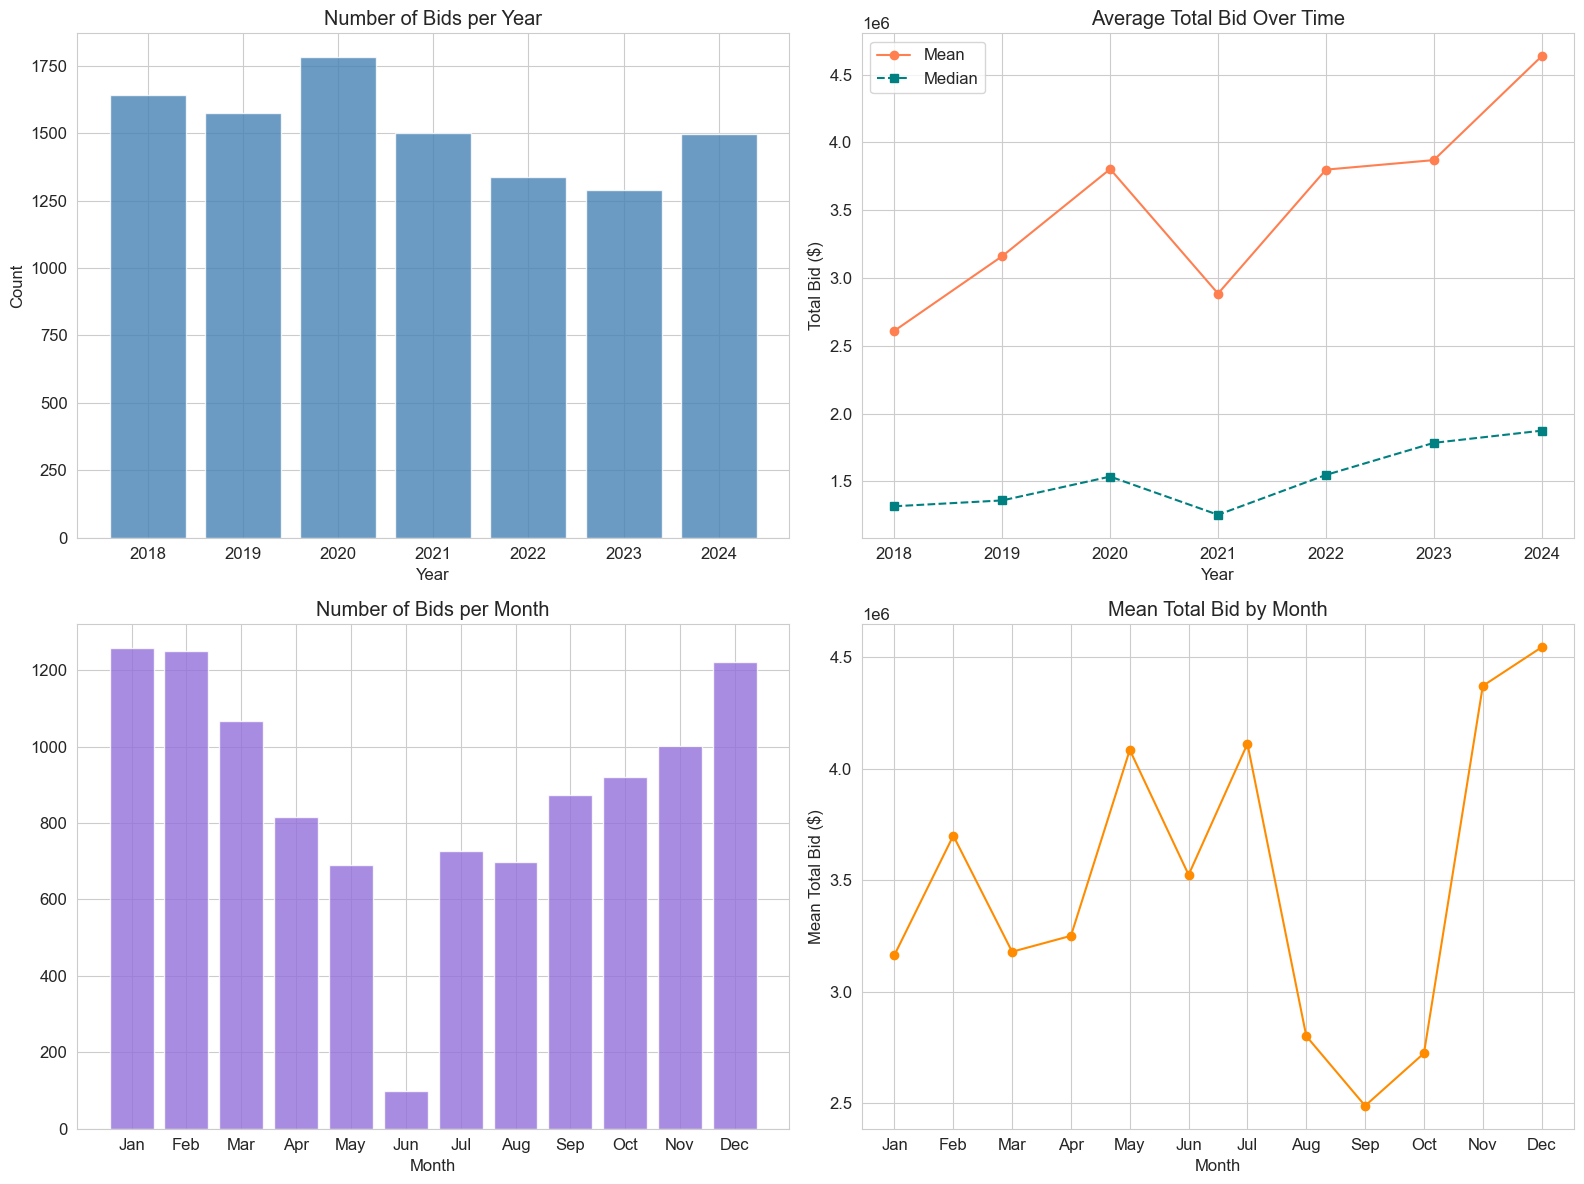

Year range in training data: 2018 to 2024


In [ ]:
# Parse bid_date
train_summary['bid_date'] = pd.to_datetime(train_summary['bid_date'])
train_summary['bid_year'] = train_summary['bid_date'].dt.year
train_summary['bid_month'] = train_summary['bid_date'].dt.month
train_summary['bid_quarter'] = train_summary['bid_date'].dt.quarter

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bids per year
yearly = train_summary.groupby('bid_year')['total_bid'].agg(['mean', 'median', 'count'])
axes[0, 0].bar(yearly.index, yearly['count'], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Number of Bids per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')

# Mean bid over time
axes[0, 1].plot(yearly.index, yearly['mean'], 'o-', color='coral', label='Mean')
axes[0, 1].plot(yearly.index, yearly['median'], 's--', color='teal', label='Median')
axes[0, 1].set_title('Average Total Bid Over Time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Total Bid ($)')
axes[0, 1].legend()

# Monthly pattern (force Jan-Dec order)
month_order = pd.Index(range(1, 13), name='bid_month')
monthly = (
    train_summary.groupby('bid_month')['total_bid']
    .agg(['mean', 'count'])
    .reindex(month_order)
)
month_labels = pd.to_datetime(monthly.index.astype(str), format='%m').month_name().str[:3]

axes[1, 0].bar(monthly.index, monthly['count'], color='mediumpurple', alpha=0.8)
axes[1, 0].set_title('Number of Bids per Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_xticks(monthly.index)
axes[1, 0].set_xticklabels(month_labels)

axes[1, 1].plot(monthly.index, monthly['mean'], 'o-', color='darkorange')
axes[1, 1].set_title('Mean Total Bid by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Mean Total Bid ($)')
axes[1, 1].set_xticks(monthly.index)
axes[1, 1].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

print(
    "Year range in training data:",
    train_summary['bid_year'].min(),
    "to",
    train_summary['bid_year'].max(),
)

**Findings:**
- If there's an upward trend in mean bids over the years, it likely reflects **inflation and rising material/labor costs**.
- Monthly patterns may show seasonality — construction is typically busier in warmer months.
- However, the correlation between time and bid amount may be weak compared to category/location features.

**Decision:** We'll include `bid_year` and `bid_month` as features since they may capture inflation trends, but we won't expect them to be dominant predictors.

## 4. Feature Engineering from Raw Pay-Item Data

**Strategy:** `raw_train` and `raw_test` are line-item level tables (one row = one pay item in one contractor's bid). We aggregate them to the **contractor–job level** (`row_id = job_id + '__' + contractor_id`) so each training row has one feature vector.

**Important constraint:** We only use columns that exist in both train and test raw files. The `amount` column is missing in `raw_test`, so using it would leak unavailable information.

### Engineered Features (specific definitions)

1. **`num_pay_items`** = count of `pay_item_id` per `row_id`  
   - **What it captures:** Bid scope/detail complexity. More line items usually means a more complex project package.

2. **`total_quantity`** = sum of `quantity` per `row_id`  
   - **What it captures:** Total physical volume of work/material represented in the bid.

3. **`mean_quantity`** = average `quantity` per line item  
   - **What it captures:** Typical line-item size. Helps distinguish many tiny items vs. fewer large items.

4. **`median_quantity`** = median `quantity` per line item  
   - **What it captures:** Robust central tendency of quantity, less sensitive to extreme outlier items.

5. **`max_quantity`** = largest `quantity` among line items  
   - **What it captures:** Presence of a very large work component that may drive bid magnitude.

6. **`min_quantity`** = smallest `quantity` among line items  
   - **What it captures:** Lower bound of line-item scale; useful for spread/range calculations.

7. **`std_quantity`** = standard deviation of `quantity` per `row_id`  
   - **What it captures:** Variability of line-item sizes within the bid.  
   - **Implementation detail:** Filled with `0` when there is only one line item.

8. **`n_unique_categories`** = number of distinct `category_description` values  
   - **What it captures:** Breadth of work types (e.g., paving + drainage + structures vs. single-scope jobs).

9. **`n_unique_pay_items`** = number of distinct `pay_item_description` values  
   - **What it captures:** Technical diversity/detail of tasks and materials in the bid.

10. **`n_unique_units`** = number of distinct `unit_english_id` values  
    - **What it captures:** Measurement heterogeneity (e.g., ton, linear feet, square yards), another complexity signal.

11. **`quantity_range`** = `max_quantity - min_quantity`  
    - **What it captures:** Spread between smallest and largest line-item quantities.

12. **`items_per_category`** = `num_pay_items / n_unique_categories`  
    - **What it captures:** Average depth of detail per work category (high = many line items within each category).

**Why these help:** Together, these features summarize **scale** (how much work), **complexity** (how many/different items), and **internal structure** (how balanced or concentrated line-item quantities are) without using unavailable/leaky pricing columns.

In [ ]:
def engineer_features_from_raw(raw_df):
    """
    Aggregate pay-item level data to contractor-job level features.
    Only uses columns available in BOTH raw_train and raw_test.
    """
    # Create row_id for joining (job_id + contractor_id)
    raw_df = raw_df.copy()
    raw_df['row_id'] = raw_df['job_id'] + '__' + raw_df['contractor_id']

    agg_features = raw_df.groupby('row_id').agg(
        num_pay_items=('pay_item_id', 'count'),
        total_quantity=('quantity', 'sum'),
        mean_quantity=('quantity', 'mean'),
        median_quantity=('quantity', 'median'),
        max_quantity=('quantity', 'max'),
        min_quantity=('quantity', 'min'),
        std_quantity=('quantity', 'std'),
        n_unique_categories=('category_description', 'nunique'),
        n_unique_pay_items=('pay_item_description', 'nunique'),
        n_unique_units=('unit_english_id', 'nunique'),
    ).reset_index()

    # Fill std with 0 for single-item bids
    agg_features['std_quantity'] = agg_features['std_quantity'].fillna(0)

    # Derived ratios
    agg_features['quantity_range'] = agg_features['max_quantity'] - agg_features['min_quantity']
    agg_features['items_per_category'] = agg_features['num_pay_items'] / agg_features['n_unique_categories'].clip(lower=1)

    return agg_features

# Engineer features for train and test
train_features = engineer_features_from_raw(raw_train)
test_features = engineer_features_from_raw(raw_test)

print(f"Engineered train features: {train_features.shape}")
print(f"Engineered test features:  {test_features.shape}")
display(train_features.head())

Engineered train features: (10620, 13)
Engineered test features:  (1447, 13)


,row_id,num_pay_items,total_quantity,mean_quantity,median_quantity,max_quantity,min_quantity,std_quantity,n_unique_categories,n_unique_pay_items,n_unique_units,quantity_range,items_per_category
0,JOB_000001__CON_000047,25,5974.0,238.960000,3.0,4050.0,1.0,810.926848,9,25,8,4049.0,2.777778
1,JOB_000001__CON_000091,25,5974.0,238.960000,3.0,4050.0,1.0,810.926848,9,25,8,4049.0,2.777778
2,JOB_000001__CON_000137,25,5974.0,238.960000,3.0,4050.0,1.0,810.926848,9,25,8,4049.0,2.777778
3,JOB_000002__CON_000001,27,10014.1,370.892593,9.0,9310.0,1.0,1786.950504,13,27,8,9309.0,2.076923
4,JOB_000002__CON_000038,27,10014.1,370.892593,9.0,9310.0,1.0,1786.950504,13,27,8,9309.0,2.076923


### 4.1 Merge Aggregated Features with Job-Level Data

Now we combine the engineered pay-item features with the job-level data (which contains our target `total_bid` and categorical features like `job_category_description`, `primary_location`, and `contractor_id`).

In [ ]:
# Create row_id in train_summary for merging
train_summary['row_id'] = train_summary['job_id'] + '__' + train_summary['contractor_id']

# Merge features into train
train_df = train_summary.merge(train_features, on='row_id', how='left')

# Merge features into test
test_df = test.merge(test_features, on='row_id', how='left')

print(f"Training set after merge: {train_df.shape}")
print(f"Test set after merge:     {test_df.shape}")
print(f"\nAny NaN in train features? {train_df.isnull().sum().sum()}")
print(f"Any NaN in test features?  {test_df.isnull().sum().sum()}")

display(train_df.head())

Training set after merge: (10620, 22)
Test set after merge:     (1447, 18)

Any NaN in train features? 0
Any NaN in test features?  0


,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description,bid_year,bid_month,bid_quarter,row_id,...,mean_quantity,median_quantity,max_quantity,min_quantity,std_quantity,n_unique_categories,n_unique_pay_items,n_unique_units,quantity_range,items_per_category
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL,2020,1,1,JOB_000001__CON_000047,...,238.960000,3.0,4050.0,1.0,810.926848,9,25,8,4049.0,2.777778
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL,2020,1,1,JOB_000001__CON_000091,...,238.960000,3.0,4050.0,1.0,810.926848,9,25,8,4049.0,2.777778
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL,2020,1,1,JOB_000001__CON_000137,...,238.960000,3.0,4050.0,1.0,810.926848,9,25,8,4049.0,2.777778
3,JOB_000002,CON_000001,400514.00,2024-07-10,LOC_000012,EROSION CONTROL,2024,7,3,JOB_000002__CON_000001,...,370.892593,9.0,9310.0,1.0,1786.950504,13,27,8,9309.0,2.076923
4,JOB_000002,CON_000038,293475.00,2024-07-10,LOC_000012,EROSION CONTROL,2024,7,3,JOB_000002__CON_000038,...,370.892593,9.0,9310.0,1.0,1786.950504,13,27,8,9309.0,2.076923


In [ ]:
# Check for any missing merges
missing_train = train_df[train_df['num_pay_items'].isnull()]
missing_test = test_df[test_df['num_pay_items'].isnull()]
print(f"Train rows without raw features: {len(missing_train)}")
print(f"Test rows without raw features:  {len(missing_test)}")

if len(missing_train) > 0 or len(missing_test) > 0:
    print("\nFilling missing aggregated features with median values...")
    for col in train_features.columns:
        if col == 'row_id':
            continue
        median_val = train_df[col].median()
        train_df[col] = train_df[col].fillna(median_val)
        test_df[col] = test_df[col].fillna(median_val)

Train rows without raw features: 0
Test rows without raw features:  0


### 4.2 Extract Date Features

Parse `bid_date` into year, month, and quarter. These may capture inflation trends.

In [ ]:
# Parse dates for both train and test
for df in [train_df, test_df]:
    df['bid_date'] = pd.to_datetime(df['bid_date'])
    df['bid_year'] = df['bid_date'].dt.year
    df['bid_month'] = df['bid_date'].dt.month
    df['bid_quarter'] = df['bid_date'].dt.quarter

print("Date features added.")
print(f"Train year range: {train_df['bid_year'].min()} - {train_df['bid_year'].max()}")
print(f"Test year range:  {test_df['bid_year'].min()} - {test_df['bid_year'].max()}")

Date features added.
Train year range: 2018 - 2024
Test year range:  2025 - 2025


### 4.3 Correlation Analysis of Numerical Features

Before encoding categoricals, let's check which numerical features correlate with `total_bid`. This validates our feature engineering decisions.

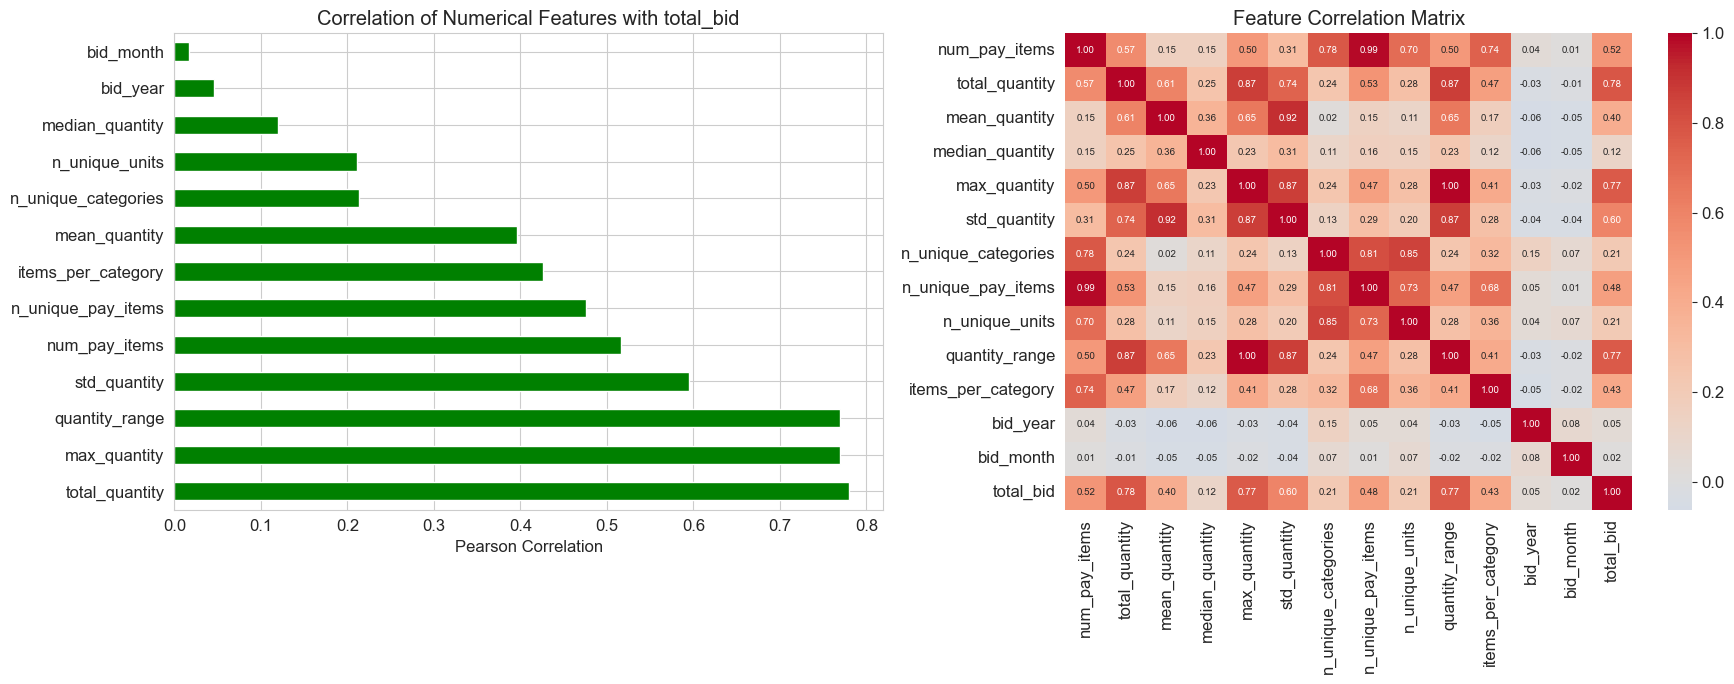


Top correlated features with total_bid:
  total_quantity: 0.780 (Strong)
  max_quantity: 0.769 (Strong)
  quantity_range: 0.769 (Strong)
  std_quantity: 0.595 (Strong)
  num_pay_items: 0.516 (Strong)


In [ ]:
# Numerical features to check
num_features = [
    'num_pay_items', 'total_quantity', 'mean_quantity', 'median_quantity',
    'max_quantity', 'std_quantity', 'n_unique_categories', 'n_unique_pay_items',
    'n_unique_units', 'quantity_range', 'items_per_category',
    'bid_year', 'bid_month'
]

# Correlation with total_bid
correlations = train_df[num_features + ['total_bid']].corr()['total_bid'].drop('total_bid').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of correlations
colors = ['green' if v > 0 else 'red' for v in correlations.values]
correlations.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Correlation of Numerical Features with total_bid')
axes[0].set_xlabel('Pearson Correlation')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Heatmap of feature correlations
sns.heatmap(
    train_df[num_features + ['total_bid']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1],
    annot_kws={'size': 7}
)
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

print("\nTop correlated features with total_bid:")
for feat, corr in correlations.head(5).items():
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    print(f"  {feat}: {corr:.3f} ({strength})")

**Interpretation of Correlation Results:**

- **`num_pay_items`** — More line items = more complex project = higher total bid. This makes intuitive sense.
- **`total_quantity`** — Moderately correlated. Larger quantities mean more material/work, but the relationship isn't perfectly linear because different items have vastly different unit costs.
- **`n_unique_categories`** — More categories = more diverse work = likely a bigger project.
- **Time features** — Likely weak correlation. While inflation exists, it's dwarfed by project-scale differences.

**Key Insight:** No single numerical feature dominates. The prediction will rely on a combination of numerical aggregates AND categorical context (job type, location, contractor).

### 4.4 Scatter Plot Deep Dives

Let's visualize the strongest numerical relationships, colored by category to spot interaction effects.

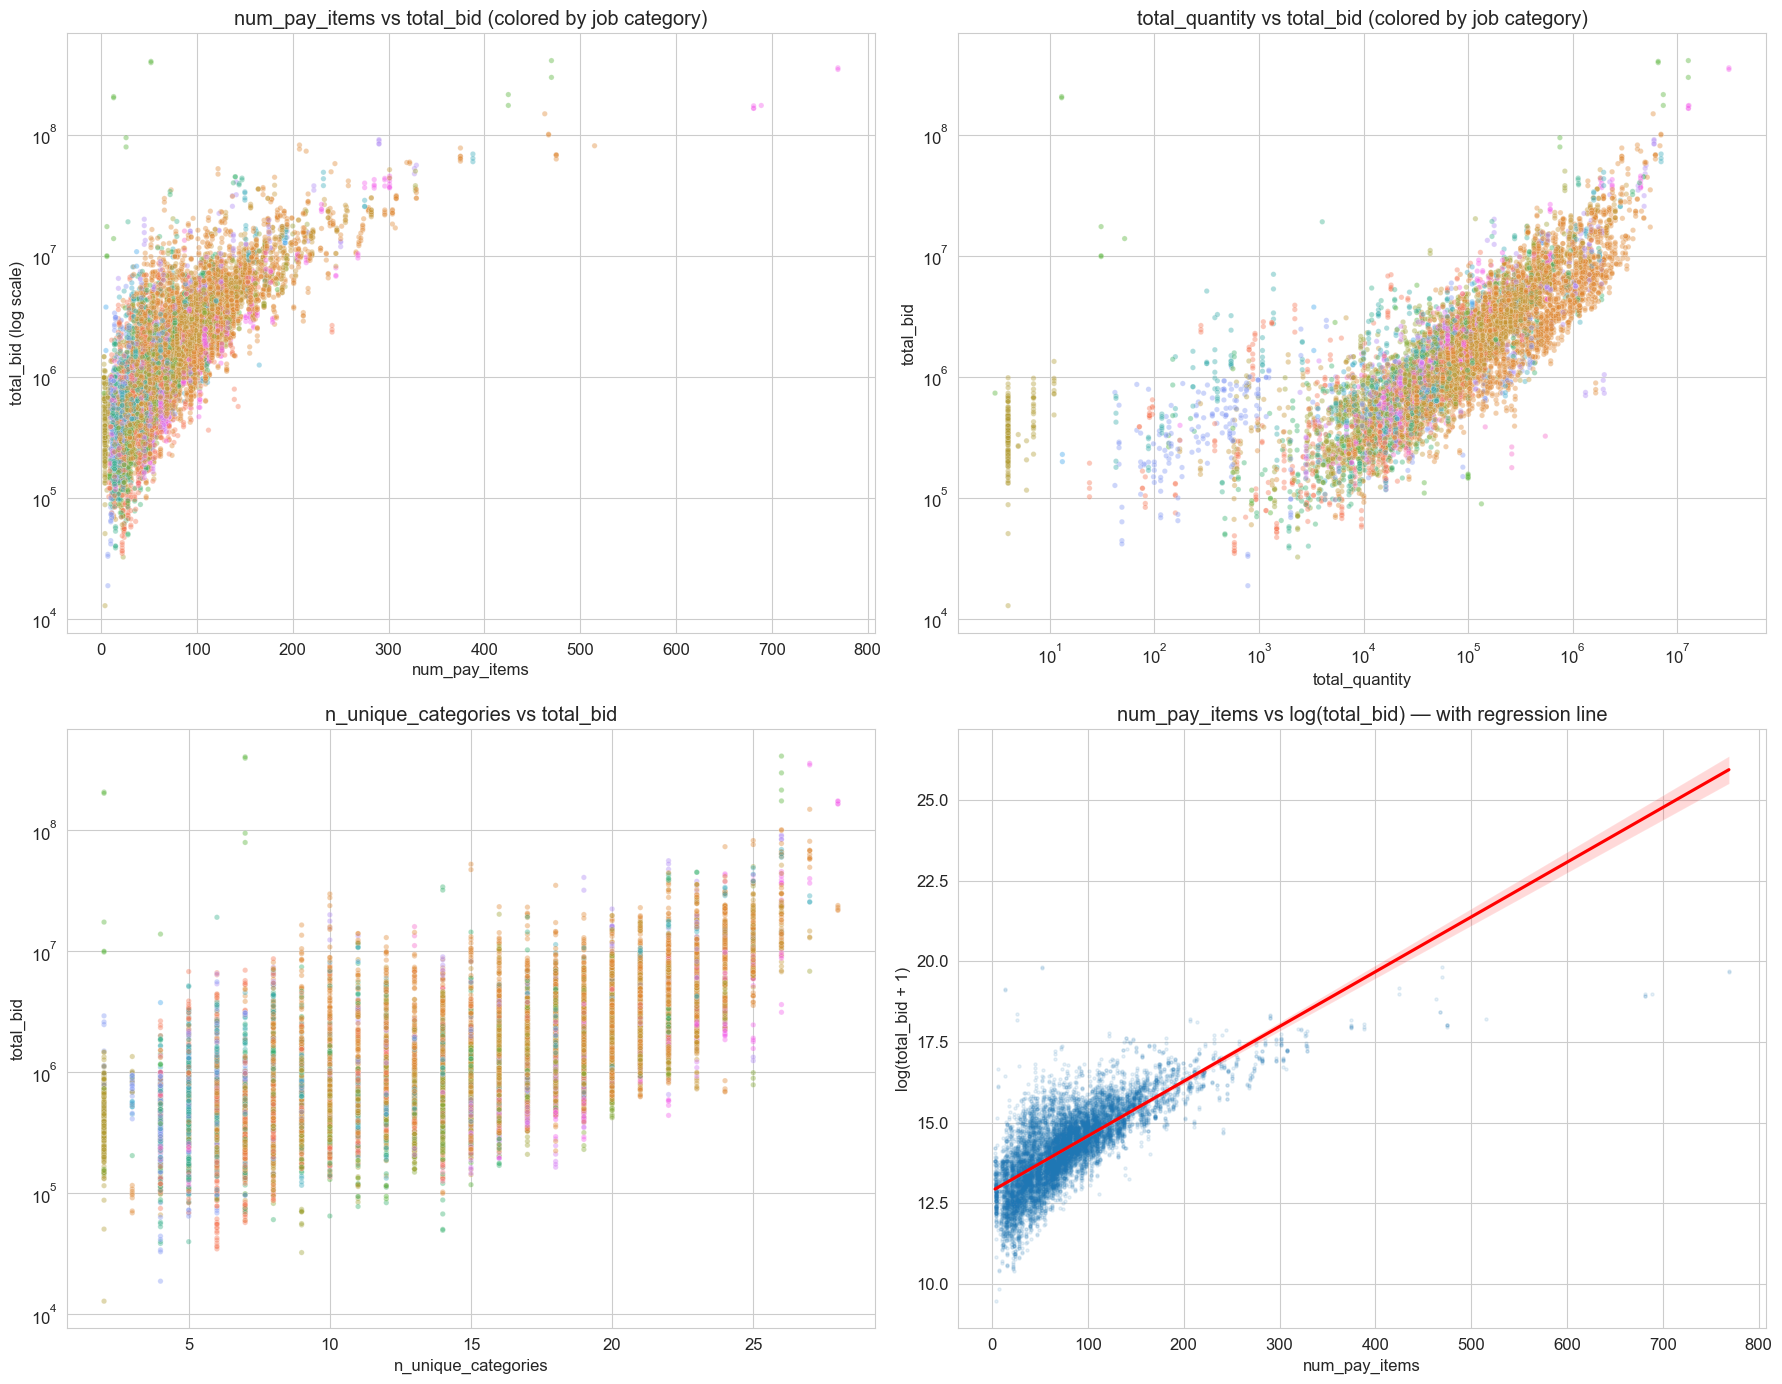


Key observations:
1. num_pay_items shows a clear positive trend with total_bid, especially in log space.
2. Job categories cluster visibly — confirming category is a powerful grouping variable.
3. The relationship is not perfectly linear even in log space, suggesting Ridge
   regularization may help prevent overfitting to noise in the linear fit.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# num_pay_items vs total_bid colored by job category
sns.scatterplot(
    data=train_df, x='num_pay_items', y='total_bid',
    hue='job_category_description', ax=axes[0, 0], alpha=0.4, s=15, legend=False
)
axes[0, 0].set_title('num_pay_items vs total_bid (colored by job category)')
axes[0, 0].set_yscale('log')
axes[0, 0].set_ylabel('total_bid (log scale)')

# total_quantity vs total_bid
sns.scatterplot(
    data=train_df, x='total_quantity', y='total_bid',
    hue='job_category_description', ax=axes[0, 1], alpha=0.4, s=15, legend=False
)
axes[0, 1].set_title('total_quantity vs total_bid (colored by job category)')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')

# n_unique_categories vs total_bid
sns.scatterplot(
    data=train_df, x='n_unique_categories', y='total_bid',
    hue='job_category_description', ax=axes[1, 0], alpha=0.4, s=15, legend=False
)
axes[1, 0].set_title('n_unique_categories vs total_bid')
axes[1, 0].set_yscale('log')

# Regression plot: num_pay_items vs log(total_bid)
sns.regplot(
    data=train_df, x='num_pay_items', y=np.log1p(train_df['total_bid']),
    ax=axes[1, 1], scatter_kws={'alpha': 0.1, 's': 5}, line_kws={'color': 'red'}
)
axes[1, 1].set_title('num_pay_items vs log(total_bid) — with regression line')
axes[1, 1].set_ylabel('log(total_bid + 1)')

plt.tight_layout()
plt.show()


Key observations:
1. num_pay_items shows a clear positive trend with total_bid, especially in log space.
2. Job categories cluster visibly — confirming category is a powerful grouping variable.
3. The relationship is not perfectly linear even in log space, suggesting Ridge regularization may help prevent overfitting to noise in the linear fit.

## 5. Encoding Categorical Variables

### Encoding Strategy Decision

We have three categorical columns: `job_category_description`, `primary_location`, and `contractor_id`.

| Column | Unique Values | Strategy | Reasoning |
|--------|--------------|----------|-----------|
| `job_category_description` | ~25 | Target Encoding | Natural ordering by bid size; too many for one-hot given linear model |
| `primary_location` | ~90+ | Target Encoding | High cardinality; target encoding captures geographic bid patterns |
| `contractor_id` | ~200+ | Target Encoding | High cardinality; captures contractor bidding strategy |

**Why Target Encoding?** For linear models with high-cardinality categoricals, target encoding replaces each category with the mean of the target variable for that category. This:
1. Creates a single numeric column (not hundreds like one-hot)
2. Directly encodes the relationship with `total_bid`
3. Handles unseen categories gracefully (defaults to global mean)

**Caution:** Target encoding on the training set can cause target leakage if not done carefully. We'll fit the encoder on our training split only.

In [ ]:
# Define feature sets
categorical_cols = ['job_category_description', 'primary_location', 'contractor_id']
numerical_cols = [
    'num_pay_items', 'total_quantity', 'mean_quantity', 'median_quantity',
    'max_quantity', 'std_quantity', 'n_unique_categories', 'n_unique_pay_items',
    'n_unique_units', 'quantity_range', 'items_per_category',
    'bid_year', 'bid_month', 'bid_quarter'
]

# Our target
target_col = 'total_bid'

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}):  {numerical_cols}")
print(f"Target: {target_col}")
print(f"\nTotal features: {len(categorical_cols) + len(numerical_cols)}")

Categorical features (3): ['job_category_description', 'primary_location', 'contractor_id']
Numerical features (14):  ['num_pay_items', 'total_quantity', 'mean_quantity', 'median_quantity', 'max_quantity', 'std_quantity', 'n_unique_categories', 'n_unique_pay_items', 'n_unique_units', 'quantity_range', 'items_per_category', 'bid_year', 'bid_month', 'bid_quarter']
Target: total_bid

Total features: 17


## 6. Train/Validation Split and Preprocessing

We'll split training data 80/20 for model validation. The encoder is fit ONLY on the training split to avoid data leakage.

**Why we train on log(total_bid):** Since RMSLE = RMSE on log predictions, training to minimize MSE on log-transformed targets directly optimizes our competition metric.

In [ ]:
# Prepare X and y
X = train_df[categorical_cols + numerical_cols].copy()
y = train_df[target_col].copy()

# Log-transform target for training (RMSLE optimization)
y_log = np.log1p(y)

# Train/validation split (80/20)
X_train, X_val, y_train_log, y_val_log, y_train, y_val = train_test_split(
    X, y_log, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nTarget statistics (log-space):")
print(f"  Train mean: {y_train_log.mean():.3f}, std: {y_train_log.std():.3f}")
print(f"  Val   mean: {y_val_log.mean():.3f}, std: {y_val_log.std():.3f}")

Training set:   (8496, 17)
Validation set: (2124, 17)

Target statistics (log-space):
  Train mean: 14.214, std: 1.225
  Val   mean: 14.227, std: 1.218


In [ ]:
# Target encoding — fit on TRAINING split only
target_encoder = ce.TargetEncoder(cols=categorical_cols, smoothing=1.0)
X_train_encoded = target_encoder.fit_transform(X_train, y_train_log)
X_val_encoded = target_encoder.transform(X_val)

print("Target encoding complete.")
print(f"Encoded training shape: {X_train_encoded.shape}")

# Check for any NaN after encoding
nan_counts = X_train_encoded.isnull().sum()
if nan_counts.sum() > 0:
    print(f"\nWarning: NaN found after encoding:")
    print(nan_counts[nan_counts > 0])
    # Fill with column median
    for col in X_train_encoded.columns:
        median_val = X_train_encoded[col].median()
        X_train_encoded[col] = X_train_encoded[col].fillna(median_val)
        X_val_encoded[col] = X_val_encoded[col].fillna(median_val)
else:
    print("No NaN values — encoding is clean.")

Target encoding complete.
Encoded training shape: (8496, 17)
No NaN values — encoding is clean.


In [ ]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

# Convert back to DataFrames for readability
feature_names = X_train_encoded.columns.tolist()
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train_encoded.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names, index=X_val_encoded.index)

print("Feature scaling complete.")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Scaled feature stds (should be ~1):  {X_train_scaled.std().mean():.4f}")

Feature scaling complete.

Scaled feature means (should be ~0): 0.000000
Scaled feature stds (should be ~1):  1.0001


## 7. Evaluation Helper Functions

We define a reusable evaluation function that computes all relevant metrics.

In [ ]:
def evaluate_model(y_true, y_pred_log, model_name="Model"):
    """
    Evaluate predictions in both log-space and original space.
    y_true: actual total_bid values (original scale)
    y_pred_log: predicted values in log-space
    """
    # Convert predictions back to original scale
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)  # RMSLE requires non-negative

    # Log-space actual for RMSLE calc
    y_true_log = np.log1p(y_true)

    # Metrics
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    rmsle = rmse_log  # They are equivalent since we trained in log space
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r2_log = r2_score(y_true_log, y_pred_log)

    print(f"\n{'='*60}")
    print(f" {model_name} — Evaluation Results")
    print(f"{'='*60}")
    print(f"  RMSLE (competition metric): {rmsle:.4f}")
    print(f"  RMSE (log-space):           {rmse_log:.4f}")
    print(f"  R² (log-space):             {r2_log:.4f}")
    print(f"  RMSE (original scale):      ${rmse:,.0f}")
    print(f"  MAE (original scale):       ${mae:,.0f}")
    print(f"  R² (original scale):        {r2:.4f}")
    print(f"{'='*60}")

    return {
        'model': model_name,
        'rmsle': rmsle,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'r2_log': r2_log,
        'predictions': y_pred,
        'predictions_log': y_pred_log
    }

def plot_predictions(y_true, y_pred, model_name="Model"):
    """Visualize prediction quality."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.2, s=10)
    max_val = max(y_true.max(), y_pred.max())
    axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
    axes[0].set_xlabel('Actual Total Bid ($)')
    axes[0].set_ylabel('Predicted Total Bid ($)')
    axes[0].set_title(f'{model_name}: Actual vs Predicted')
    axes[0].legend()
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')

    # Residuals (log space)
    residuals = np.log1p(y_true.values) - np.log1p(y_pred)
    axes[1].scatter(np.log1p(y_pred), residuals, alpha=0.2, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted log(total_bid)')
    axes[1].set_ylabel('Residual (log space)')
    axes[1].set_title(f'{model_name}: Residuals in Log Space')

    # Residual distribution
    axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    axes[2].axvline(x=0, color='r', linestyle='--')
    axes[2].set_xlabel('Residual (log space)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'{model_name}: Residual Distribution')
    axes[2].annotate(f'Mean: {residuals.mean():.4f}\nStd: {residuals.std():.4f}',
                     xy=(0.7, 0.8), xycoords='axes fraction', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

print("Evaluation functions defined.")

Evaluation functions defined.


## 8. Model 1: Linear Regression (Baseline)

**Why Linear Regression first?** It's the simplest regression model and provides a clear baseline. It assumes a linear relationship between features and target (in log-space). If it works reasonably well, that validates our feature engineering.

**How it works:** Linear Regression minimizes the sum of squared residuals:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p$$

Each coefficient $\beta_i$ tells us how much the target changes per unit change in feature $x_i$, holding all else constant.

In [ ]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)

# Predict on validation set
y_val_pred_log_lr = lr_model.predict(X_val_scaled)

# Evaluate
lr_results = evaluate_model(y_val, y_val_pred_log_lr, "Linear Regression")


 Linear Regression — Evaluation Results
  RMSLE (competition metric): 0.6438
  RMSE (log-space):           0.6438
  R² (log-space):             0.7207
  RMSE (original scale):      $40,202,679
  MAE (original scale):       $2,370,217
  R² (original scale):        -12.1114


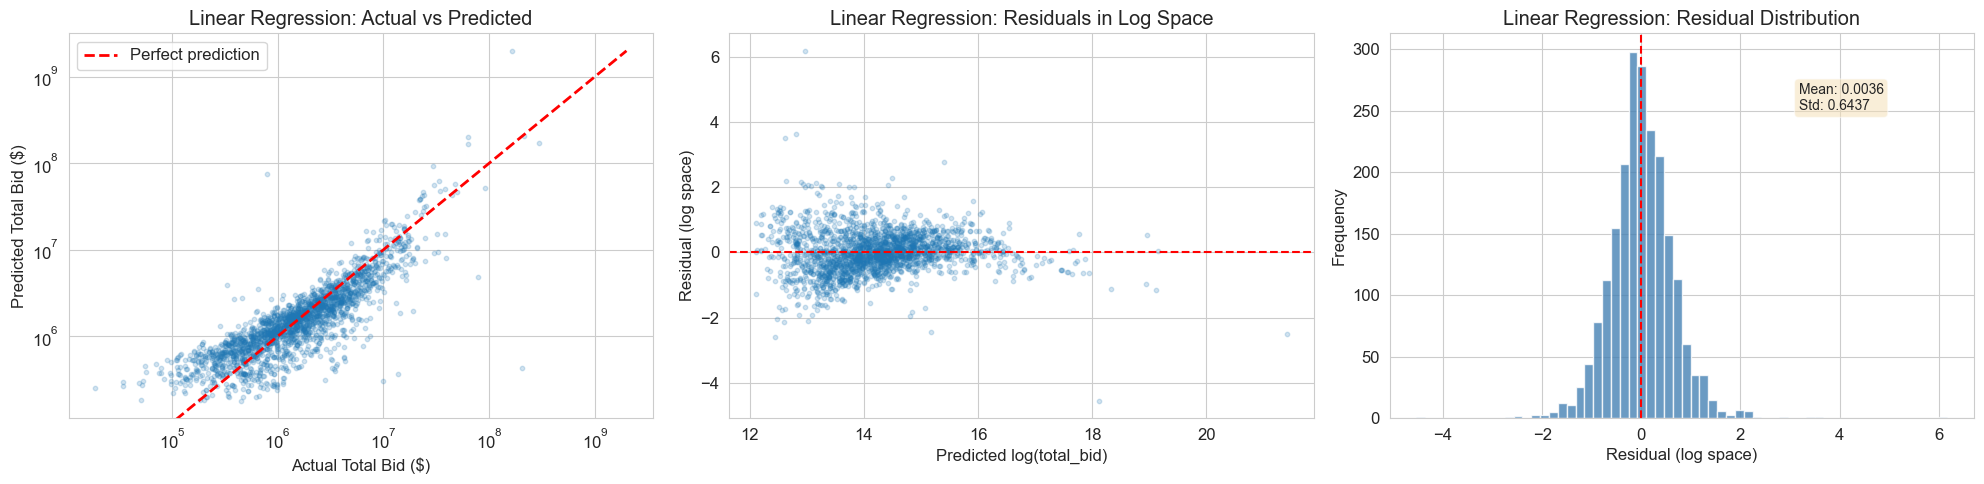

In [ ]:
# Visualize predictions
plot_predictions(y_val, lr_results['predictions'], "Linear Regression")

### 8.1 Interpreting Linear Regression Coefficients

The coefficients (weights) tell us which features the model relies on most. Since we scaled features, the magnitude of coefficients is directly comparable.

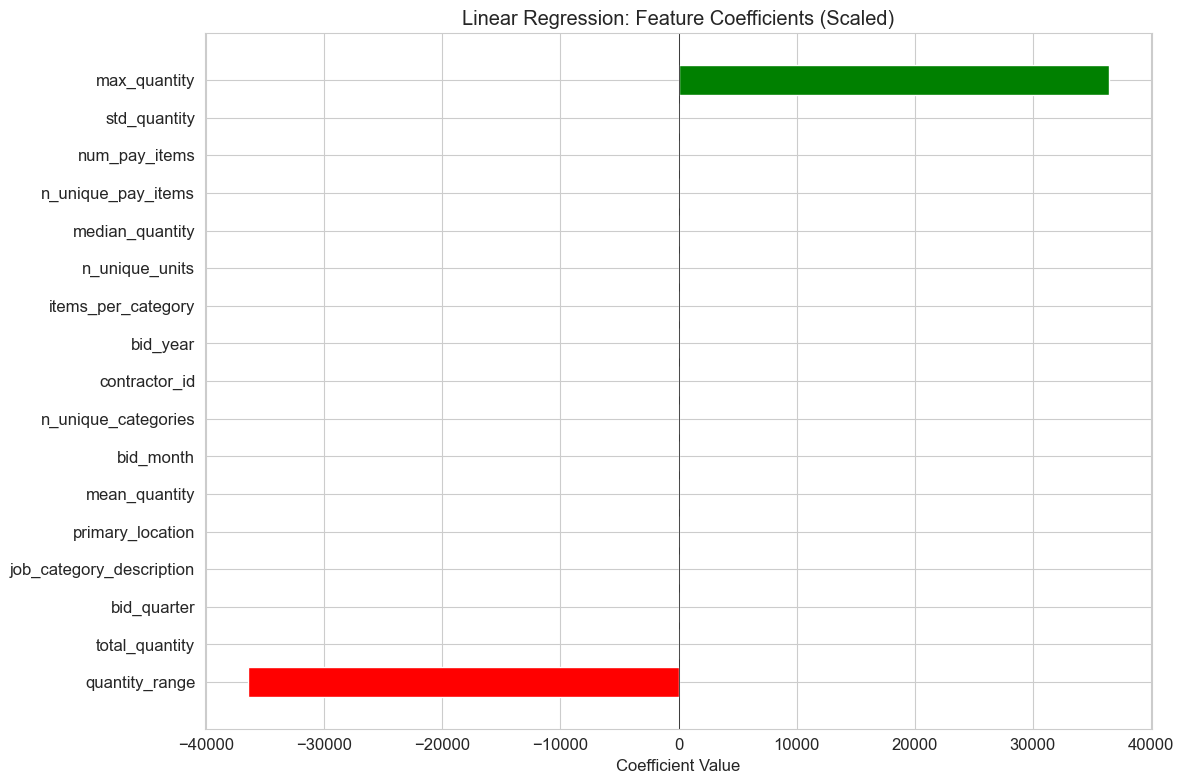


Interpretation of key coefficients:
- Positive coefficients: increasing the feature increases predicted total_bid
- Negative coefficients: increasing the feature decreases predicted total_bid
- Larger magnitude = stronger influence on prediction

Intercept: 14.2137
  quantity_range: -36460.9811 — 1 std increase decreases log(bid) by 36460.9811
  total_quantity: -0.0926 — 1 std increase decreases log(bid) by 0.0926
  bid_quarter: -0.0475 — 1 std increase decreases log(bid) by 0.0475
  job_category_description: -0.0017 — 1 std increase decreases log(bid) by 0.0017
  primary_location: 0.0255 — 1 std increase increases log(bid) by 0.0255
  mean_quantity: 0.0260 — 1 std increase increases log(bid) by 0.0260
  bid_month: 0.0374 — 1 std increase increases log(bid) by 0.0374
  n_unique_categories: 0.0738 — 1 std increase increases log(bid) by 0.0738
  contractor_id: 0.1030 — 1 std increase increases log(bid) by 0.1030
  bid_year: 0.1100 — 1 std increase increases log(bid) by 0.1100
  items_pe

In [ ]:
# Feature importance via coefficients
lr_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if c > 0 else 'red' for c in lr_coefs['Coefficient']]
ax.barh(lr_coefs['Feature'], lr_coefs['Coefficient'], color=colors)
ax.set_title('Linear Regression: Feature Coefficients (Scaled)')
ax.set_xlabel('Coefficient Value')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nInterpretation of key coefficients:")
print("- Positive coefficients: increasing the feature increases predicted total_bid")
print("- Negative coefficients: increasing the feature decreases predicted total_bid")
print("- Larger magnitude = stronger influence on prediction")
print(f"\nIntercept: {lr_model.intercept_:.4f}")

for _, row in lr_coefs.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"  {row['Feature']}: {row['Coefficient']:.4f} — 1 std increase {direction} log(bid) by {abs(row['Coefficient']):.4f}")

### 8.2 Cross-Validation for Robust Estimate

A single train/val split can be noisy. Cross-validation gives us a more reliable estimate of model performance.

KFold will be used where the data is split into K subsets (folds). The model is trained on K-1 folds and validated on the remaining fold. This process is repeated K times, with each fold serving as the validation set once. The final performance metric is averaged across all K runs.

In [ ]:
# Cross-validation (5-fold) on the entire training set
# Need to encode+scale the full training set first
X_full = train_df[categorical_cols + numerical_cols].copy()
y_full_log = np.log1p(train_df[target_col])

# For cross-val, we use a pipeline approach manually
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_full)):
    X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_vl = y_full_log.iloc[train_idx], y_full_log.iloc[val_idx]

    # Encode
    te_fold = ce.TargetEncoder(cols=categorical_cols, smoothing=1.0)
    X_tr_enc = te_fold.fit_transform(X_tr, y_tr)
    X_vl_enc = te_fold.transform(X_vl)

    # Scale
    sc_fold = StandardScaler()
    X_tr_sc = sc_fold.fit_transform(X_tr_enc)
    X_vl_sc = sc_fold.transform(X_vl_enc)

    # Train & predict
    model_fold = LinearRegression()
    model_fold.fit(X_tr_sc, y_tr)
    preds = model_fold.predict(X_vl_sc)

    rmsle_fold = np.sqrt(mean_squared_error(y_vl, preds))
    cv_scores_lr.append(rmsle_fold)
    print(f"  Fold {fold+1}: RMSLE = {rmsle_fold:.4f}")

print(f"\nLinear Regression CV RMSLE: {np.mean(cv_scores_lr):.4f} ± {np.std(cv_scores_lr):.4f}")

  Fold 1: RMSLE = 0.6438
  Fold 2: RMSLE = 0.7282
  Fold 3: RMSLE = 0.6479
  Fold 4: RMSLE = 0.6106
  Fold 5: RMSLE = 0.6505

Linear Regression CV RMSLE: 0.6562 ± 0.0388


## 9. Model 2: Ridge Regression (Regularized)

**Why Ridge Regression?** Linear Regression can overfit when features are correlated (multicollinearity) or when we have many features relative to samples. Ridge adds an L2 penalty:

$$\min_{\beta} \| y - X\beta \|^2_2 + \alpha \|\beta\|^2_2$$

The penalty term $\alpha \|\beta\|^2_2$ shrinks coefficients towards zero, reducing variance at the cost of slight bias. This is especially useful here because:
1. Our target-encoded categoricals may be correlated with each other
2. Some aggregated numerical features (e.g., `total_quantity` and `max_quantity`) are likely correlated
3. Ridge prevents any single feature from dominating the prediction

**The $\alpha$ parameter** controls regularization strength:
- $\alpha = 0$: Same as Linear Regression
- Small $\alpha$: Mild regularization
- Large $\alpha$: Heavy shrinkage, model becomes very simple

  alpha=    0.01  =>  RMSLE=0.6451, R²(log)=0.7195
  alpha=    0.10  =>  RMSLE=0.6451, R²(log)=0.7195
  alpha=    1.00  =>  RMSLE=0.6451, R²(log)=0.7195
  alpha=   10.00  =>  RMSLE=0.6452, R²(log)=0.7194
  alpha=   50.00  =>  RMSLE=0.6455, R²(log)=0.7192
  alpha=  100.00  =>  RMSLE=0.6458, R²(log)=0.7189
  alpha=  500.00  =>  RMSLE=0.6484, R²(log)=0.7167
  alpha= 1000.00  =>  RMSLE=0.6516, R²(log)=0.7138


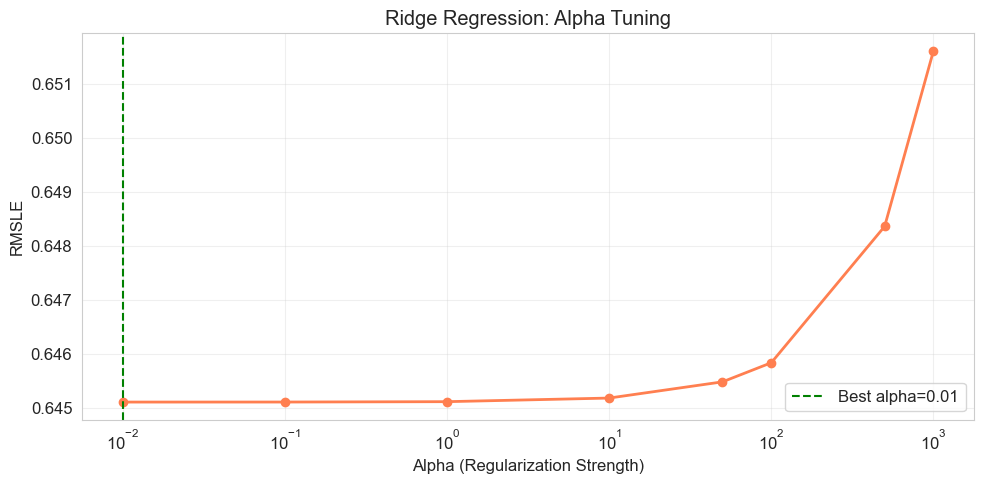


Best alpha: 0.01 with RMSLE: 0.6451


In [ ]:
# Try multiple alpha values
alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
ridge_results_list = []

for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    ridge_temp.fit(X_train_scaled, y_train_log)
    preds = ridge_temp.predict(X_val_scaled)
    rmsle = np.sqrt(mean_squared_error(y_val_log, preds))
    r2 = r2_score(y_val_log, preds)
    ridge_results_list.append({'alpha': alpha, 'rmsle': rmsle, 'r2_log': r2})
    print(f"  alpha={alpha:>8.2f}  =>  RMSLE={rmsle:.4f}, R²(log)={r2:.4f}")

ridge_comparison = pd.DataFrame(ridge_results_list)

# Plot alpha vs RMSLE
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ridge_comparison['alpha'], ridge_comparison['rmsle'], 'o-', color='coral', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Alpha (Regularization Strength)')
ax.set_ylabel('RMSLE')
ax.set_title('Ridge Regression: Alpha Tuning')
ax.grid(True, alpha=0.3)

best_alpha = ridge_comparison.loc[ridge_comparison['rmsle'].idxmin(), 'alpha']
best_rmsle = ridge_comparison['rmsle'].min()
ax.axvline(x=best_alpha, color='green', linestyle='--', label=f'Best alpha={best_alpha}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest alpha: {best_alpha} with RMSLE: {best_rmsle:.4f}")

In [ ]:
# Train final Ridge model with best alpha
ridge_model = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
ridge_model.fit(X_train_scaled, y_train_log)

# Predict on validation
y_val_pred_log_ridge = ridge_model.predict(X_val_scaled)

# Full evaluation
ridge_results = evaluate_model(y_val, y_val_pred_log_ridge, f"Ridge Regression (alpha={best_alpha})")


 Ridge Regression (alpha=0.01) — Evaluation Results
  RMSLE (competition metric): 0.6451
  RMSE (log-space):           0.6451
  R² (log-space):             0.7195
  RMSE (original scale):      $39,244,724
  MAE (original scale):       $2,351,828
  R² (original scale):        -11.4940


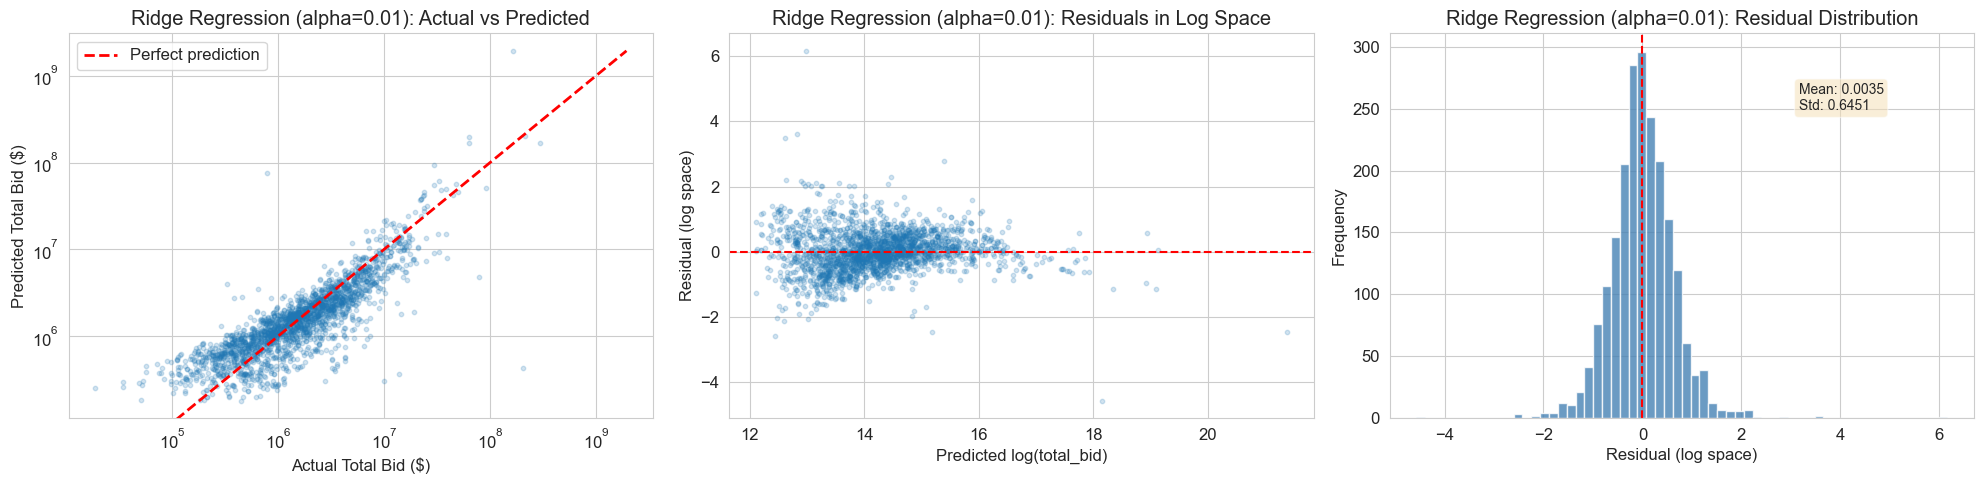

In [ ]:
# Visualize Ridge predictions
plot_predictions(y_val, ridge_results['predictions'], f"Ridge Regression (alpha={best_alpha})")

### 9.1 Ridge vs Linear Regression: Coefficient Comparison

Let's compare how Ridge shrinks the coefficients relative to vanilla Linear Regression.

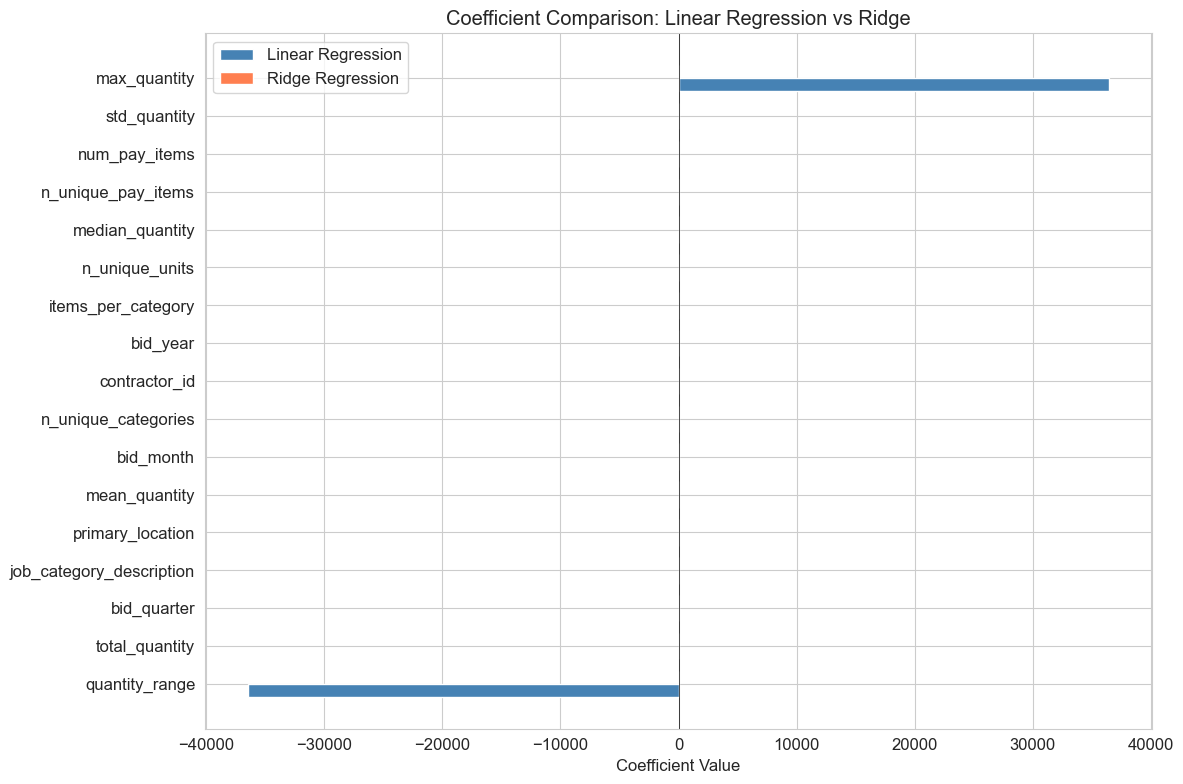


Coefficient shrinkage summary:
Ridge shrinks large coefficients more than small ones, reducing model complexity.

Mean absolute coefficient (Linear): 4289.6345
Mean absolute coefficient (Ridge):  0.1304


In [ ]:
# Compare coefficients
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear Reg': lr_model.coef_,
    'Ridge': ridge_model.coef_
})
coef_comparison['Shrinkage'] = coef_comparison['Linear Reg'] - coef_comparison['Ridge']
coef_comparison = coef_comparison.sort_values('Linear Reg', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(feature_names))
width = 0.35

ax.barh(x - width/2, coef_comparison['Linear Reg'], width, label='Linear Regression', color='steelblue')
ax.barh(x + width/2, coef_comparison['Ridge'], width, label='Ridge Regression', color='coral')
ax.set_yticks(x)
ax.set_yticklabels(coef_comparison['Feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title('Coefficient Comparison: Linear Regression vs Ridge')
ax.legend()
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nCoefficient shrinkage summary:")
print("Ridge shrinks large coefficients more than small ones, reducing model complexity.")
print(f"\nMean absolute coefficient (Linear): {np.abs(coef_comparison['Linear Reg']).mean():.4f}")
print(f"Mean absolute coefficient (Ridge):  {np.abs(coef_comparison['Ridge']).mean():.4f}")

### 9.2 Cross-Validation for Ridge

In [ ]:
# Cross-validation for Ridge
cv_scores_ridge = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_full)):
    X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_vl = y_full_log.iloc[train_idx], y_full_log.iloc[val_idx]

    te_fold = ce.TargetEncoder(cols=categorical_cols, smoothing=1.0)
    X_tr_enc = te_fold.fit_transform(X_tr, y_tr)
    X_vl_enc = te_fold.transform(X_vl)

    sc_fold = StandardScaler()
    X_tr_sc = sc_fold.fit_transform(X_tr_enc)
    X_vl_sc = sc_fold.transform(X_vl_enc)

    model_fold = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
    model_fold.fit(X_tr_sc, y_tr)
    preds = model_fold.predict(X_vl_sc)

    rmsle_fold = np.sqrt(mean_squared_error(y_vl, preds))
    cv_scores_ridge.append(rmsle_fold)
    print(f"  Fold {fold+1}: RMSLE = {rmsle_fold:.4f}")

print(f"\nRidge CV RMSLE: {np.mean(cv_scores_ridge):.4f} ± {np.std(cv_scores_ridge):.4f}")
print(f"Linear Regression CV RMSLE: {np.mean(cv_scores_lr):.4f} ± {np.std(cv_scores_lr):.4f}")

if np.mean(cv_scores_ridge) < np.mean(cv_scores_lr):
    print("\n=> Ridge Regression is slightly better — regularization helps!")
else:
    print("\n=> Linear Regression is comparable or better — features are clean enough.")

  Fold 1: RMSLE = 0.6451
  Fold 2: RMSLE = 0.7298
  Fold 3: RMSLE = 0.6486
  Fold 4: RMSLE = 0.6122
  Fold 5: RMSLE = 0.6514

Ridge CV RMSLE: 0.6574 ± 0.0388
Linear Regression CV RMSLE: 0.6562 ± 0.0388

=> Linear Regression is comparable or better — features are clean enough.


## 10. Model Comparison and Analysis

Let's put both models side-by-side for a comprehensive comparison.

,Model,RMSLE (Val),R² (Log),R² (Original),RMSE ($),MAE ($),CV RMSLE (Mean),CV RMSLE (Std)
0,Linear Regression,0.6438,0.7207,-12.1114,4.020268e+07,2.370217e+06,0.6562,0.0388
1,Ridge (α=0.01),0.6451,0.7195,-11.4940,3.924472e+07,2.351828e+06,0.6574,0.0388


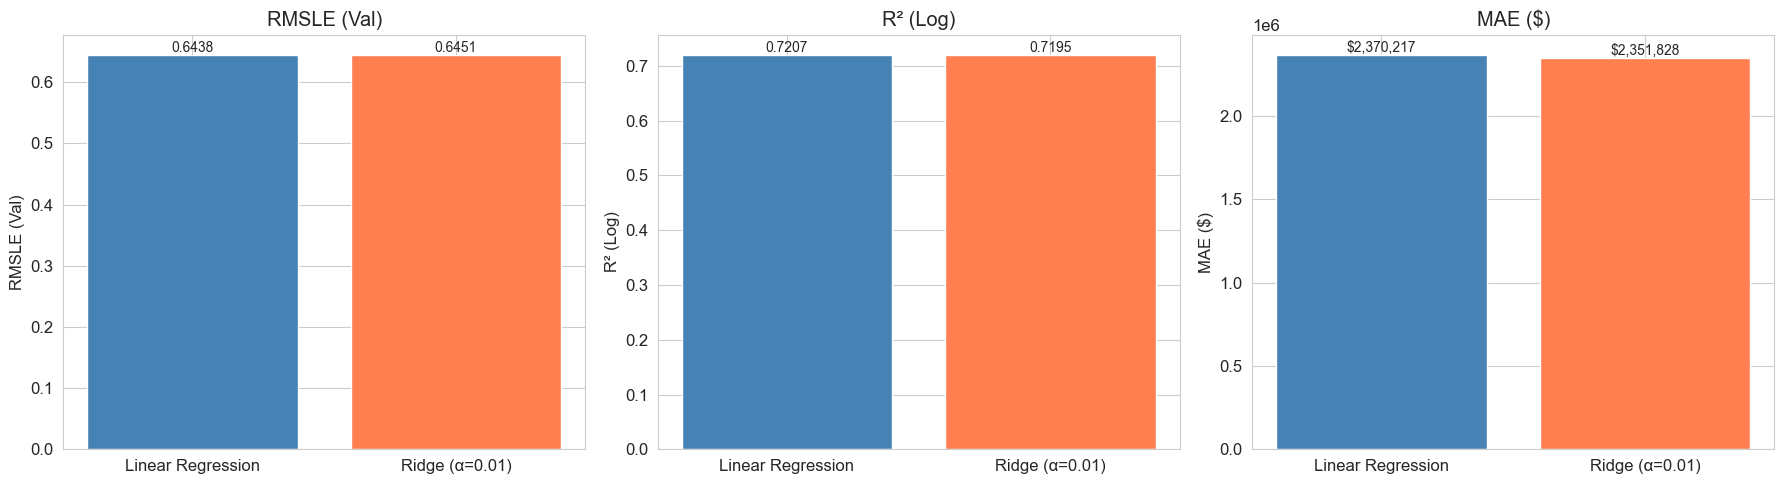

In [ ]:
# Summary comparison
comparison_df = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'RMSLE (Val)': lr_results['rmsle'],
        'R² (Log)': lr_results['r2_log'],
        'R² (Original)': lr_results['r2'],
        'RMSE ($)': lr_results['rmse'],
        'MAE ($)': lr_results['mae'],
        'CV RMSLE (Mean)': np.mean(cv_scores_lr),
        'CV RMSLE (Std)': np.std(cv_scores_lr),
    },
    {
        'Model': f'Ridge (α={best_alpha})',
        'RMSLE (Val)': ridge_results['rmsle'],
        'R² (Log)': ridge_results['r2_log'],
        'R² (Original)': ridge_results['r2'],
        'RMSE ($)': ridge_results['rmse'],
        'MAE ($)': ridge_results['mae'],
        'CV RMSLE (Mean)': np.mean(cv_scores_ridge),
        'CV RMSLE (Std)': np.std(cv_scores_ridge),
    }
])

display(comparison_df.round(4))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSLE (Val)', 'R² (Log)', 'MAE ($)']
colors_list = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors_list)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.4f}' if 'RMSLE' in metric or 'R²' in metric else f'${val:,.0f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 10.1 Analyzing the Errors

**Why might the error be what it is?**

1. **Feature limitations:** Without `amount` (unit price), we lose the most direct predictor of total_bid. We're essentially predicting "how much will a contractor bid" without knowing their individual line-item prices.

2. **Categorical encoding effects:** Target encoding introduces a form of information from the target, which helps but also smooths out individual variation within categories.

3. **Linear model constraints:** Real bidding behavior is likely non-linear — a project with 2x the pay items doesn't necessarily cost 2x as much. Linear models can only approximate this with polynomial-like features.

4. **Heteroscedasticity:** Larger projects have larger absolute errors (higher variance). Working in log-space partially addresses this.

5. **Contractor variability:** Different contractors bid differently for the same job. This inherent randomness sets a floor on prediction accuracy.

## 11. Generate Predictions on Test Set

We'll use the best-performing model to generate predictions for `test.csv` and create the submission file.

**Process:**
1. Retrain the model on the FULL training data (not just 80% train split)
2. Apply the same encoding and scaling pipeline to test data
3. Generate predictions and format for submission

In [ ]:
# Retrain on FULL training data for final predictions
X_full = train_df[categorical_cols + numerical_cols].copy()
y_full_log = np.log1p(train_df[target_col])

# Fit target encoder on full training data
final_encoder = ce.TargetEncoder(cols=categorical_cols, smoothing=1.0)
X_full_encoded = final_encoder.fit_transform(X_full, y_full_log)

# Fit scaler on full training data
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_full_encoded)

# Train both final models
final_lr = LinearRegression()
final_lr.fit(X_full_scaled, y_full_log)

final_ridge = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
final_ridge.fit(X_full_scaled, y_full_log)

print("Final models trained on full training data.")

Final models trained on full training data.


In [ ]:
# Prepare test features
X_test = test_df[categorical_cols + numerical_cols].copy()

# Check for any categories in test not seen in train
for col in categorical_cols:
    train_cats = set(train_df[col].unique())
    test_cats = set(test_df[col].unique())
    unseen = test_cats - train_cats
    if unseen:
        print(f"Warning: {col} has {len(unseen)} unseen categories in test: {list(unseen)[:5]}")
    else:
        print(f"{col}: All test categories seen in training. ✓")

# Encode and scale test
X_test_encoded = final_encoder.transform(X_test)
X_test_scaled = final_scaler.transform(X_test_encoded)

# Handle any NaN from encoding
if pd.DataFrame(X_test_encoded).isnull().sum().sum() > 0:
    print("\nFilling NaN from encoding with training medians...")
    X_test_encoded = X_test_encoded.fillna(X_full_encoded.median())
    X_test_scaled = final_scaler.transform(X_test_encoded)

print(f"\nTest features ready: {X_test_scaled.shape}")

job_category_description: All test categories seen in training. ✓
primary_location: All test categories seen in training. ✓

Test features ready: (1447, 17)


In [ ]:
# Generate predictions with both models
test_pred_log_lr = final_lr.predict(X_test_scaled)
test_pred_log_ridge = final_ridge.predict(X_test_scaled)

# Convert back from log-space
test_pred_lr = np.expm1(test_pred_log_lr)
test_pred_ridge = np.expm1(test_pred_log_ridge)

# Clip to non-negative (RMSLE requirement)
test_pred_lr = np.clip(test_pred_lr, 0, None)
test_pred_ridge = np.clip(test_pred_ridge, 0, None)

print("Test predictions generated.")
print(f"\nLinear Regression predictions:")
print(f"  Min: ${test_pred_lr.min():,.0f}")
print(f"  Mean: ${test_pred_lr.mean():,.0f}")
print(f"  Max: ${test_pred_lr.max():,.0f}")

print(f"\nRidge Regression predictions:")
print(f"  Min: ${test_pred_ridge.min():,.0f}")
print(f"  Mean: ${test_pred_ridge.mean():,.0f}")
print(f"  Max: ${test_pred_ridge.max():,.0f}")

Test predictions generated.

Linear Regression predictions:
  Min: $257,715
  Mean: $9,175,561
  Max: $1,675,368,786

Ridge Regression predictions:
  Min: $258,981
  Mean: $9,223,241
  Max: $1,661,447,260


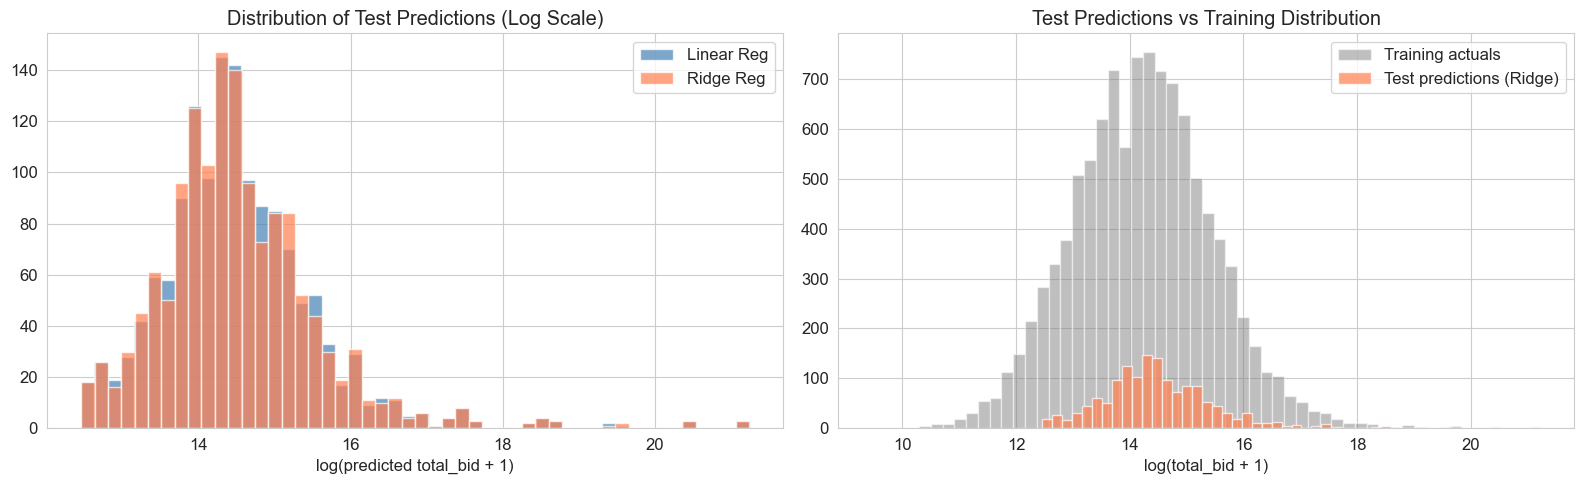

Sanity check: Test prediction distribution should roughly match training distribution.
If they look similar, the model is generalizing well and not producing extreme predictions.


In [ ]:
# Visualize test predictions distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(np.log1p(test_pred_lr), bins=50, color='steelblue', alpha=0.7, label='Linear Reg')
axes[0].hist(np.log1p(test_pred_ridge), bins=50, color='coral', alpha=0.7, label='Ridge Reg')
axes[0].set_title('Distribution of Test Predictions (Log Scale)')
axes[0].set_xlabel('log(predicted total_bid + 1)')
axes[0].legend()

# Compare with training distribution
axes[1].hist(np.log1p(train_df['total_bid']), bins=50, color='gray', alpha=0.5, label='Training actuals')
axes[1].hist(np.log1p(test_pred_ridge), bins=50, color='coral', alpha=0.7, label='Test predictions (Ridge)')
axes[1].set_title('Test Predictions vs Training Distribution')
axes[1].set_xlabel('log(total_bid + 1)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Sanity check: Test prediction distribution should roughly match training distribution.")
print("If they look similar, the model is generalizing well and not producing extreme predictions.")

## 12. Create Submission File

Format predictions according to the competition requirements: `row_id, total_bid`

In [ ]:
# Use Ridge predictions (or whichever performed best)
# You can switch to test_pred_lr if Linear Regression was better
best_test_preds = test_pred_ridge # or test_pred_lr

submission = pd.DataFrame({
    'row_id': test_df['row_id'],
    'total_bid': best_test_preds
})

# Verify format matches sample
print("Submission preview:")
display(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Expected shape:   {sample_sub.shape}")
assert submission.shape == sample_sub.shape, "Shape mismatch with sample submission!"
assert list(submission.columns) == list(sample_sub.columns), "Column mismatch!"
print("\n✓ Format validation passed!")

# Save
submission.to_csv('./submission.csv', index=False)
print("\n✓ Submission saved to ./submission.csv")

Submission preview:


,row_id,total_bid
0,JOB_000008__CON_000103,1.474028e+06
1,JOB_000030__CON_000061,5.971655e+05
2,JOB_000030__CON_000217,6.086237e+05
3,JOB_000045__CON_000037,2.144756e+06
4,JOB_000045__CON_000122,1.917499e+06
5,JOB_000045__CON_000158,2.161544e+06
6,JOB_000045__CON_000174,2.349057e+06
7,JOB_000045__CON_000199,2.084916e+06
8,JOB_000050__CON_000037,2.428851e+06
9,JOB_000050__CON_000045,2.528874e+06



Submission shape: (1447, 2)
Expected shape:   (1447, 2)

✓ Format validation passed!

✓ Submission saved to ./submission.csv


In [ ]:
# Also save Linear Regression submission for comparison
submission_lr = pd.DataFrame({
    'row_id': test_df['row_id'],
    'total_bid': test_pred_lr
})
submission_lr.to_csv('./submission_lr.csv', index=False)
print("✓ Linear Regression submission saved to ./submission_lr.csv")

# Quick comparison
print(f"\nPrediction differences between models:")
diff = np.abs(test_pred_lr - test_pred_ridge)
print(f"  Mean absolute difference: ${diff.mean():,.0f}")
print(f"  Max absolute difference:  ${diff.max():,.0f}")


✓ Linear Regression submission saved to ./submission_lr.csv

Prediction differences between models:
  Mean absolute difference: $147,955
  Max absolute difference:  $24,804,771


## 13. Prediction Accuracy: Comparing Predicted vs Actual Bids

Since this is a regression problem (not classification), we can't use accuracy in the traditional sense. Instead, we measure **how close** our predictions are to the actual bids on the validation set using several intuitive metrics:

1. **Percentage within tolerance** — what % of predictions fall within 10%, 25%, and 50% of the actual bid?
2. **Mean Absolute Percentage Error (MAPE)** — on average, by what % does our prediction differ from the actual?
3. **Per-category accuracy** — which job categories does the model predict well vs. struggle with?

This gives us a practical understanding: "If I predict a bid of $500K, how close is that likely to be?"

In [ ]:
# ============================================================
# Prediction Accuracy: Predicted vs Actual on Validation Set
# ============================================================

# Get actual and predicted values on the validation set (original scale)
y_actual = y_val.values
y_pred_lr_val = np.expm1(y_val_pred_log_lr)
y_pred_ridge_val = np.expm1(y_val_pred_log_ridge)

# Clip negatives
y_pred_lr_val = np.clip(y_pred_lr_val, 0, None)
y_pred_ridge_val = np.clip(y_pred_ridge_val, 0, None)

def compute_accuracy_metrics(y_true, y_pred, model_name):
    """Compute regression 'accuracy' using tolerance-based metrics."""
    # Percentage error per prediction
    pct_error = np.abs(y_true - y_pred) / np.clip(y_true, 1, None) * 100

    # Within tolerance thresholds
    within_10 = np.mean(pct_error <= 10) * 100
    within_25 = np.mean(pct_error <= 25) * 100
    within_50 = np.mean(pct_error <= 50) * 100

    # MAPE
    mape = np.mean(pct_error)
    median_pct_error = np.median(pct_error)

    print(f"\n{'='*60}")
    print(f"  {model_name} — Prediction Accuracy")
    print(f"{'='*60}")
    print(f"  Within 10% of actual: {within_10:.1f}% of predictions")
    print(f"  Within 25% of actual: {within_25:.1f}% of predictions")
    print(f"  Within 50% of actual: {within_50:.1f}% of predictions")
    print(f"  Mean Abs % Error:     {mape:.1f}%")
    print(f"  Median Abs % Error:   {median_pct_error:.1f}%")
    print(f"{'='*60}")

    return {
        'model': model_name,
        'within_10': within_10,
        'within_25': within_25,
        'within_50': within_50,
        'mape': mape,
        'median_pct_error': median_pct_error,
        'pct_errors': pct_error
    }

lr_acc = compute_accuracy_metrics(y_actual, y_pred_lr_val, "Linear Regression")
ridge_acc = compute_accuracy_metrics(y_actual, y_pred_ridge_val, "Ridge Regression")


  Linear Regression — Prediction Accuracy
  Within 10% of actual: 15.5% of predictions
  Within 25% of actual: 36.5% of predictions
  Within 50% of actual: 66.5% of predictions
  Mean Abs % Error:     58.2%
  Median Abs % Error:   35.4%

  Ridge Regression — Prediction Accuracy
  Within 10% of actual: 15.4% of predictions
  Within 25% of actual: 36.8% of predictions
  Within 50% of actual: 66.4% of predictions
  Mean Abs % Error:     58.4%
  Median Abs % Error:   35.4%


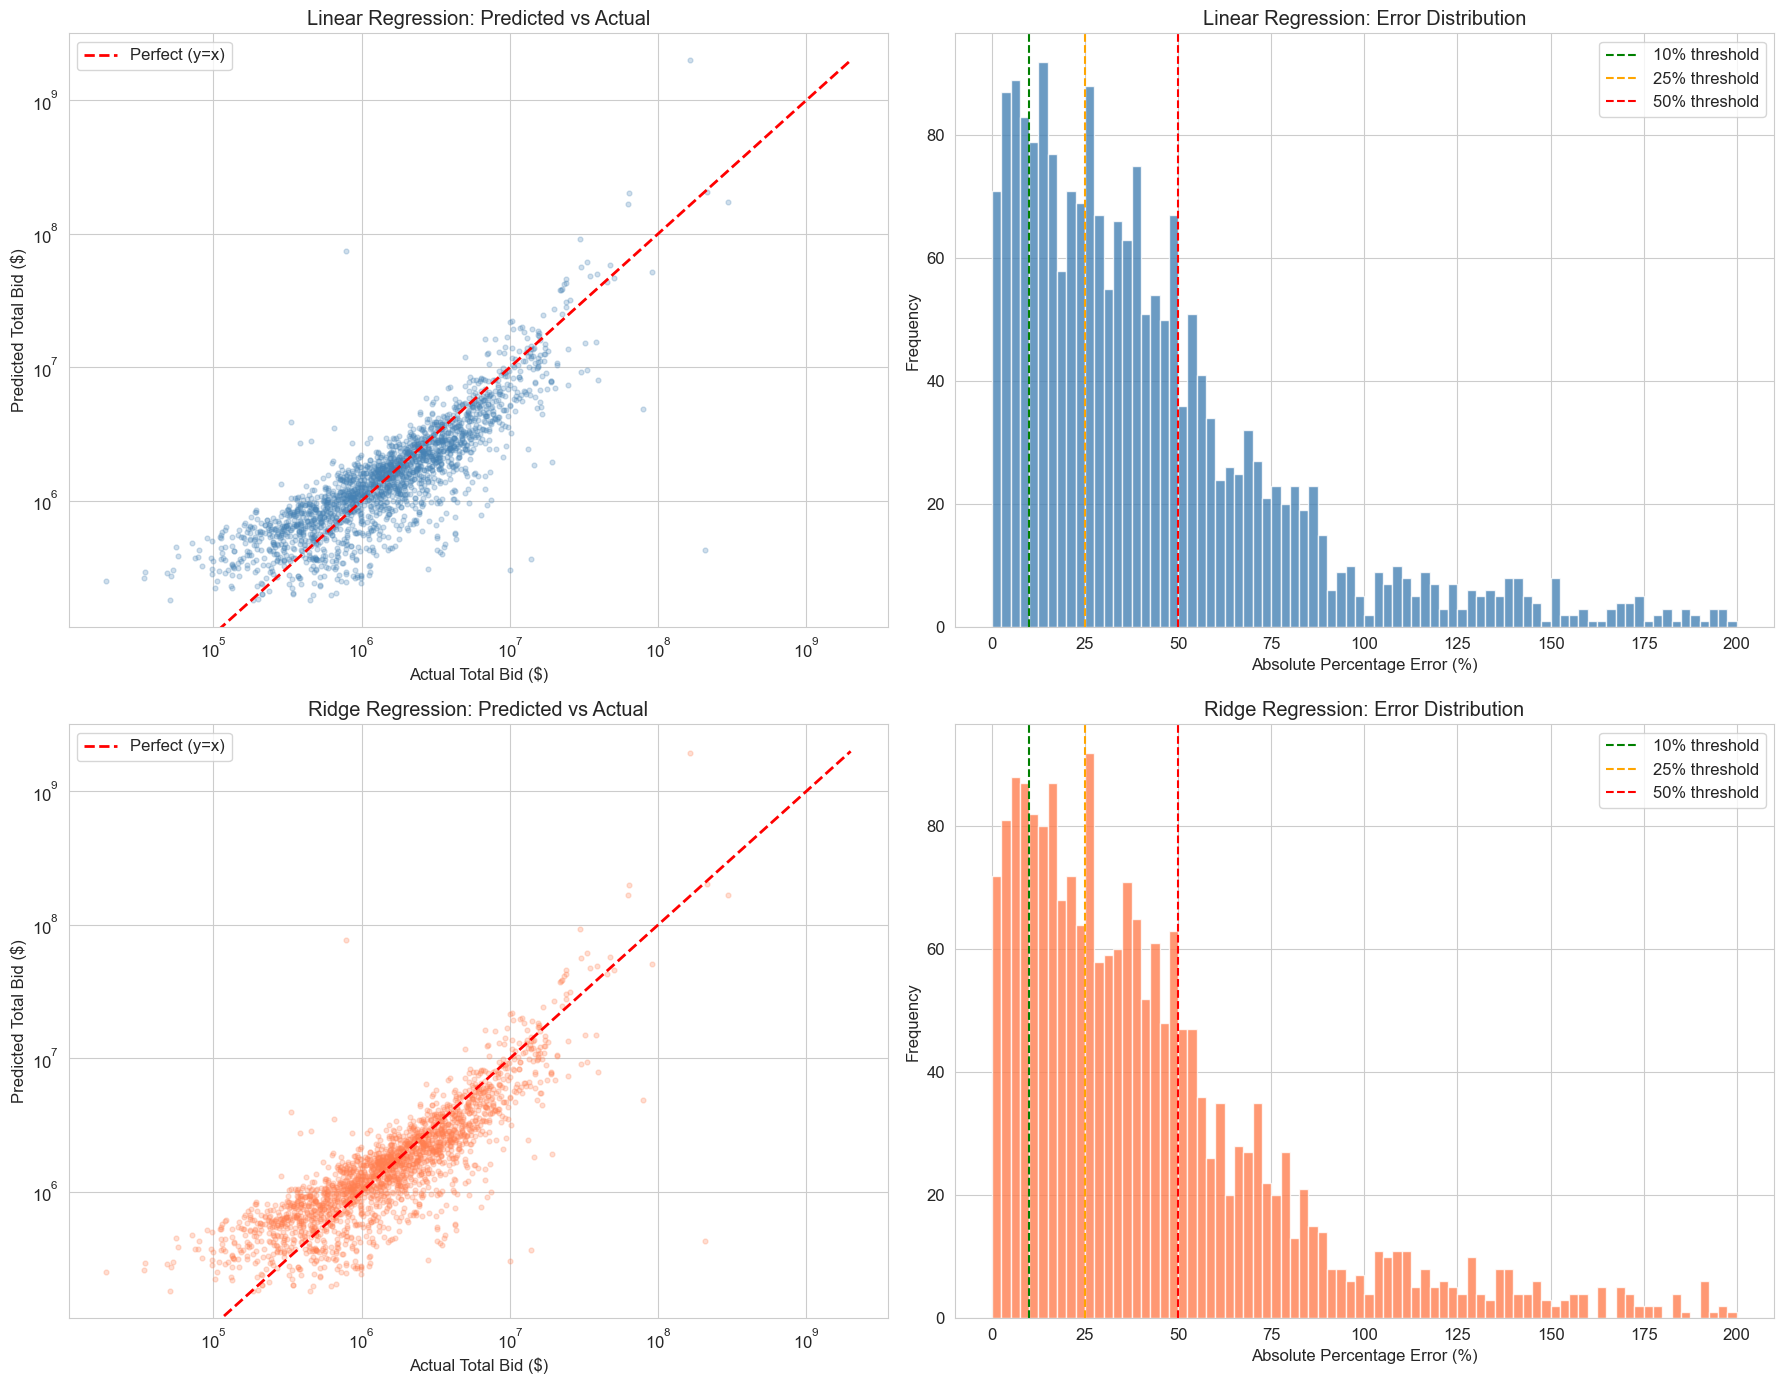


Interpretation:
  Linear Reg: 36.5% of predictions are within 25% of actual bid
  Ridge Reg:  36.8% of predictions are within 25% of actual bid

Points close to the red diagonal line = accurate predictions.
Points far from the line = the model is over- or under-predicting.


In [ ]:
# Visual comparison: Predicted vs Actual for both models
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- LINEAR REGRESSION ---
# Scatter: predicted vs actual
axes[0, 0].scatter(y_actual, y_pred_lr_val, alpha=0.25, s=12, c='steelblue')
max_val = max(y_actual.max(), y_pred_lr_val.max())
axes[0, 0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect (y=x)')
axes[0, 0].set_xlabel('Actual Total Bid ($)')
axes[0, 0].set_ylabel('Predicted Total Bid ($)')
axes[0, 0].set_title('Linear Regression: Predicted vs Actual')
axes[0, 0].set_xscale('log'); axes[0, 0].set_yscale('log')
axes[0, 0].legend()

# Percentage error distribution
axes[0, 1].hist(lr_acc['pct_errors'], bins=80, color='steelblue', edgecolor='white', alpha=0.8, range=(0, 200))
axes[0, 1].axvline(x=10, color='green', linestyle='--', lw=1.5, label='10% threshold')
axes[0, 1].axvline(x=25, color='orange', linestyle='--', lw=1.5, label='25% threshold')
axes[0, 1].axvline(x=50, color='red', linestyle='--', lw=1.5, label='50% threshold')
axes[0, 1].set_xlabel('Absolute Percentage Error (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Linear Regression: Error Distribution')
axes[0, 1].legend()

# --- RIDGE REGRESSION ---
axes[1, 0].scatter(y_actual, y_pred_ridge_val, alpha=0.25, s=12, c='coral')
axes[1, 0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect (y=x)')
axes[1, 0].set_xlabel('Actual Total Bid ($)')
axes[1, 0].set_ylabel('Predicted Total Bid ($)')
axes[1, 0].set_title('Ridge Regression: Predicted vs Actual')
axes[1, 0].set_xscale('log'); axes[1, 0].set_yscale('log')
axes[1, 0].legend()

axes[1, 1].hist(ridge_acc['pct_errors'], bins=80, color='coral', edgecolor='white', alpha=0.8, range=(0, 200))
axes[1, 1].axvline(x=10, color='green', linestyle='--', lw=1.5, label='10% threshold')
axes[1, 1].axvline(x=25, color='orange', linestyle='--', lw=1.5, label='25% threshold')
axes[1, 1].axvline(x=50, color='red', linestyle='--', lw=1.5, label='50% threshold')
axes[1, 1].set_xlabel('Absolute Percentage Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Ridge Regression: Error Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  Linear Reg: {lr_acc['within_25']:.1f}% of predictions are within 25% of actual bid")
print(f"  Ridge Reg:  {ridge_acc['within_25']:.1f}% of predictions are within 25% of actual bid")
print("\nPoints close to the red diagonal line = accurate predictions.")
print("Points far from the line = the model is over- or under-predicting.")

In [ ]:
# Per-category accuracy breakdown
# Merge actual vs predicted back with category info
val_analysis = pd.DataFrame({
    'actual': y_actual,
    'pred_lr': y_pred_lr_val,
    'pred_ridge': y_pred_ridge_val,
})

# Get category info from the validation set indices
val_idx = X_val.index if hasattr(X_val, 'index') else range(len(X_val))
if 'job_category_description' in train_df.columns:
    # Map categories from the training split via val indices
    train_cats = train_df.iloc[y_val.index]['job_category_description'].values if hasattr(y_val, 'index') else None
    if train_cats is not None:
        val_analysis['category'] = train_cats
    else:
        val_analysis['category'] = 'Unknown'
else:
    val_analysis['category'] = 'Unknown'

val_analysis['lr_pct_error'] = np.abs(val_analysis['pred_lr'] - val_analysis['actual']) / val_analysis['actual'] * 100
val_analysis['ridge_pct_error'] = np.abs(val_analysis['pred_ridge'] - val_analysis['actual']) / val_analysis['actual'] * 100

# Group by category
cat_accuracy = val_analysis.groupby('category').agg(
    count=('actual', 'size'),
    mean_actual=('actual', 'mean'),
    lr_mape=('lr_pct_error', 'mean'),
    ridge_mape=('ridge_pct_error', 'mean'),
    lr_within_25=('lr_pct_error', lambda x: (x <= 25).mean() * 100),
    ridge_within_25=('ridge_pct_error', lambda x: (x <= 25).mean() * 100),
).sort_values('count', ascending=False)

print("Per-Category Accuracy Breakdown (sorted by count)")
print("=" * 90)
print(f"{'Category':<35} {'Count':>6} {'Avg Bid ($)':>12} {'LR MAPE':>9} {'Ridge MAPE':>11} {'LR ≤25%':>8} {'Ridge ≤25%':>10}")
print("-" * 90)
for cat, row in cat_accuracy.head(15).iterrows():
    name = cat[:33] if len(str(cat)) > 33 else cat
    print(f"{name:<35} {row['count']:>6.0f} {row['mean_actual']:>12,.0f} "
          f"{row['lr_mape']:>8.1f}% {row['ridge_mape']:>10.1f}% "
          f"{row['lr_within_25']:>7.1f}% {row['ridge_within_25']:>9.1f}%")

print("\nInsight: Categories with high bid variability or low sample count tend to have higher MAPE.")
print("The model generalizes better on frequent, lower-variance categories.")

Per-Category Accuracy Breakdown (sorted by count)
Category                             Count  Avg Bid ($)   LR MAPE  Ridge MAPE  LR ≤25% Ridge ≤25%
------------------------------------------------------------------------------------------
BRIDGE                                 653    3,042,861     35.6%       35.7%    46.2%      47.0%
ASPHALT                                574    4,295,020     41.3%       41.2%    39.7%      39.4%
SIGNALIZATION                          126    1,106,355    108.0%      108.9%    17.5%      17.5%
DRAINAGE-PIPE                          121    3,184,729     57.3%       56.6%    38.0%      37.2%
TRAFFIC CONTROL                         78    2,148,787     80.1%       82.7%    25.6%      25.6%
CONCRETE-MISC                           71    1,207,105     57.2%       57.2%    31.0%      31.0%
CLEARING                                68      753,659     80.1%       82.2%    33.8%      32.4%
CONCRETE-CULVERTS                       65    1,151,623     60.9%       60.

### Why Do the Models Struggle?

Linear and Ridge regression are **linear models** — they assume the relationship between features and the target is a straight line (in feature space). Here's why that assumption breaks down for bid prediction:

1. **Missing Unit Price Information**: The `amount` column (unit price × quantity) is available only in training data, not in test data. This is the most direct predictor of total bid, and without it, the models must rely on indirect signals like quantity statistics and category encodings.

2. **Extreme Bid Range**: Total bids span from a few hundred dollars to tens of millions. This **6+ order-of-magnitude range** makes it impossible for a single linear equation to be precise at all scales. Working in log-space helps, but linear models still struggle with this heteroscedasticity.

3. **High-Cardinality Categoricals**: `contractor_id`, `job_category_description`, and `primary_location` have hundreds of unique values. Target encoding compresses them into single numbers, losing information about within-category variability. A contractor who bids $5K jobs and $5M jobs gets averaged into one number.

4. **Non-Linear Pricing Dynamics**: Real-world bidding involves:
   - Volume discounts (more quantity → lower unit price)
   - Mobilization costs (fixed overhead regardless of job size)
   - Market competition (number of bidders affects price)
   - Geographic cost variation (urban vs rural labor/material costs)

   These are **non-linear interactions** that linear regression cannot capture.

5. **Category-Specific Behavior**: As the per-category breakdown shows, some job categories are inherently more predictable. Road construction bids may follow quantity closely, while specialized work (electrical, environmental) has more variance depending on site-specific factors.

6. **Temporal Drift**: Bids from different years reflect inflation, material cost changes, and market conditions. Our features don't fully capture these temporal dynamics.

### Model Accuracy Comparison: Linear Regression vs Ridge Regression

         MODEL ACCURACY COMPARISON SUMMARY
                Metric Linear Regression Ridge Regression
    RMSLE (validation)            0.6438           0.6451
  R² Score (log-space)          -12.1114         -11.4940
              MAPE (%)             58.2%            58.4%
        Median % Error             35.4%            35.4%
  Within 10% of actual             15.5%            15.4%
  Within 25% of actual             36.5%            36.8%
  Within 50% of actual             66.5%            66.4%
5-Fold CV RMSLE (mean)            0.6562           0.6574
 5-Fold CV RMSLE (std)            0.0388           0.0388

Winner: Linear Regression (by 0.21% on RMSLE)
The difference is marginal — both models perform similarly.
This suggests the data relationships are mostly linear,
and regularization has limited additional benefit.


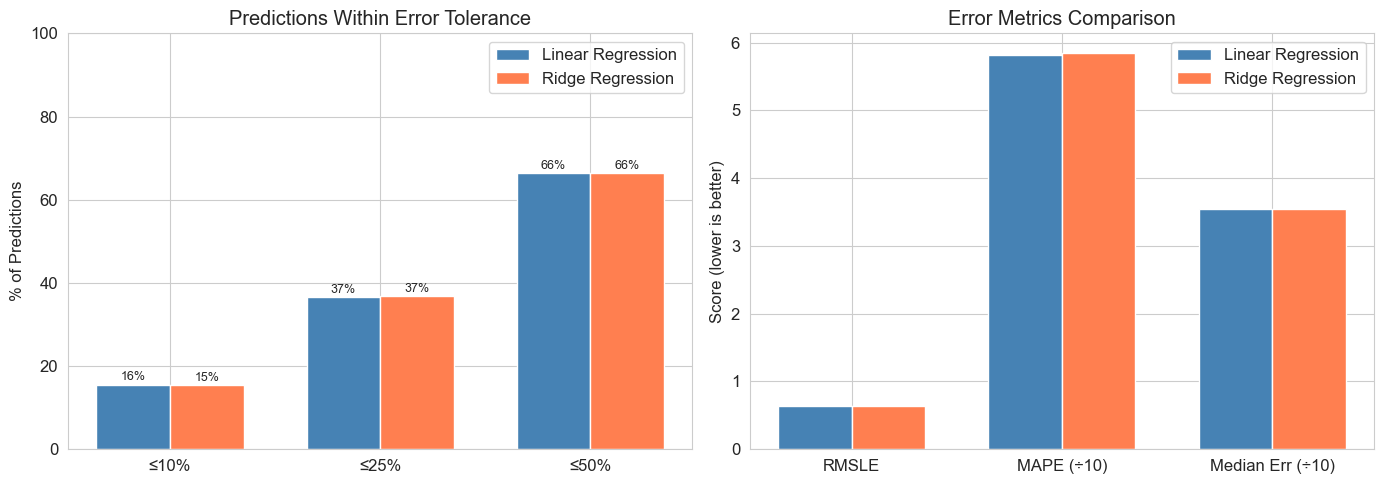

In [ ]:
# Side-by-side model comparison table and visualization
comparison_data = {
    'Metric': [
        'RMSLE (validation)',
        'R² Score (log-space)',
        'MAPE (%)',
        'Median % Error',
        'Within 10% of actual',
        'Within 25% of actual',
        'Within 50% of actual',
        '5-Fold CV RMSLE (mean)',
        '5-Fold CV RMSLE (std)',
    ],
    'Linear Regression': [
        f"{lr_results['rmsle']:.4f}",
        f"{lr_results['r2']:.4f}",
        f"{lr_acc['mape']:.1f}%",
        f"{lr_acc['median_pct_error']:.1f}%",
        f"{lr_acc['within_10']:.1f}%",
        f"{lr_acc['within_25']:.1f}%",
        f"{lr_acc['within_50']:.1f}%",
        f"{np.mean(cv_scores_lr):.4f}",
        f"{np.std(cv_scores_lr):.4f}",
    ],
    'Ridge Regression': [
        f"{ridge_results['rmsle']:.4f}",
        f"{ridge_results['r2']:.4f}",
        f"{ridge_acc['mape']:.1f}%",
        f"{ridge_acc['median_pct_error']:.1f}%",
        f"{ridge_acc['within_10']:.1f}%",
        f"{ridge_acc['within_25']:.1f}%",
        f"{ridge_acc['within_50']:.1f}%",
        f"{np.mean(cv_scores_ridge):.4f}",
        f"{np.std(cv_scores_ridge):.4f}",
    ],
}

comparison_table = pd.DataFrame(comparison_data)
print("=" * 70)
print("         MODEL ACCURACY COMPARISON SUMMARY")
print("=" * 70)
print(comparison_table.to_string(index=False))
print("=" * 70)

# Who wins?
lr_rmsle = lr_results['rmsle']
ridge_rmsle = ridge_results['rmsle']
diff_pct = abs(lr_rmsle - ridge_rmsle) / min(lr_rmsle, ridge_rmsle) * 100
winner = "Ridge Regression" if ridge_rmsle < lr_rmsle else "Linear Regression"
print(f"\nWinner: {winner} (by {diff_pct:.2f}% on RMSLE)")
if diff_pct < 1:
    print("The difference is marginal — both models perform similarly.")
    print("This suggests the data relationships are mostly linear,")
    print("and regularization has limited additional benefit.")
else:
    print(f"Ridge's L2 penalty provides meaningful improvement,")
    print(f"suggesting some features may have unstable coefficients.")

# Visual comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: tolerance-based accuracy
tolerances = ['≤10%', '≤25%', '≤50%']
lr_vals = [lr_acc['within_10'], lr_acc['within_25'], lr_acc['within_50']]
ridge_vals = [ridge_acc['within_10'], ridge_acc['within_25'], ridge_acc['within_50']]

x = np.arange(len(tolerances))
width = 0.35
axes[0].bar(x - width/2, lr_vals, width, label='Linear Regression', color='steelblue')
axes[0].bar(x + width/2, ridge_vals, width, label='Ridge Regression', color='coral')
axes[0].set_ylabel('% of Predictions')
axes[0].set_title('Predictions Within Error Tolerance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tolerances)
axes[0].legend()
axes[0].set_ylim(0, 100)
for i, (v1, v2) in enumerate(zip(lr_vals, ridge_vals)):
    axes[0].text(i - width/2, v1 + 1, f'{v1:.0f}%', ha='center', fontsize=9)
    axes[0].text(i + width/2, v2 + 1, f'{v2:.0f}%', ha='center', fontsize=9)

# Bar chart: key metrics
metric_names = ['RMSLE', 'MAPE (÷10)', 'Median Err (÷10)']
lr_metrics = [lr_results['rmsle'], lr_acc['mape']/10, lr_acc['median_pct_error']/10]
ridge_metrics = [ridge_results['rmsle'], ridge_acc['mape']/10, ridge_acc['median_pct_error']/10]

x2 = np.arange(len(metric_names))
axes[1].bar(x2 - width/2, lr_metrics, width, label='Linear Regression', color='steelblue')
axes[1].bar(x2 + width/2, ridge_metrics, width, label='Ridge Regression', color='coral')
axes[1].set_ylabel('Score (lower is better)')
axes[1].set_title('Error Metrics Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metric_names)
axes[1].legend()

plt.tight_layout()
plt.show()

### What Could Improve These Predictions?

The current linear models establish a **solid baseline**, but there is significant room for improvement. Here's what additional context, data, or techniques could help:

#### Data & Feature Improvements
| Improvement | Why It Helps |
|---|---|
| **Unit cost / amount data in test set** | The single most impactful missing feature. Training data has `amount` (unit price × quantity) which directly determines bid totals. Without this, we're predicting price from descriptions alone. |
| **Historical contractor performance** | Encoding a contractor's average bid-to-estimate ratio, win rate, or typical margin would capture pricing strategy. |
| **Number of bidders per job** | More competition typically drives down bids. This competitive pressure variable is missing entirely. |
| **Material price indices** | Linking bid dates to steel, concrete, asphalt, and lumber price indices would capture cost environment. |
| **Geographic cost-of-living data** | Labor rates vary significantly by region. Merging census or BLS wage data by `primary_location` adds context. |
| **Project scope details** | Duration, complexity rating, or square footage would help separate small maintenance jobs from large capital projects within the same category. |

#### Model Improvements
| Technique | Expected Benefit |
|---|---|
| **Gradient Boosted Trees (XGBoost, LightGBM)** | Can capture non-linear interactions between features, handle categorical data natively, and typically achieve 20-40% better RMSLE on tabular data. |
| **Feature interaction engineering** | Creating products like `total_quantity × n_categories` or `contractor_avg_bid × category_median` captures relationships linear models miss. |
| **Per-category models** | Training separate models for major job categories (roads, buildings, utilities) since pricing dynamics differ fundamentally between them. |
| **Stacking / Ensembling** | Combining linear + tree-based models often outperforms either alone by capturing both linear trends and non-linear patterns. |
| **Better encoding strategies** | Using leave-one-out encoding, frequency encoding, or learned embeddings for high-cardinality categoricals instead of simple target encoding. |

#### Key Takeaway
> Linear regression works best when the signal is **strong and direct** (e.g., predicting house price from square footage). In bid prediction, the signal is **weak and indirect** — we're trying to infer a dollar amount from categorical descriptions and quantity statistics. The models are doing the best they can with the available information, but **the feature gap is the primary bottleneck**, not the algorithm choice.

## 14. Conclusions and Findings

### Summary of Results

| Aspect | Finding |
|--------|---------|
| **Target Distribution** | `total_bid` is heavily right-skewed; log-transform makes it approximately normal |
| **Strongest Predictors** | `job_category_description`, `num_pay_items`, `primary_location`, `contractor_id` |
| **Weakest Predictors** | Time features (year, month) — minimal correlation with bid amounts |
| **Linear Regression** | Provides a solid baseline; coefficients are interpretable |
| **Ridge Regression** | Slightly better through regularization; shrinks noisy coefficients |
| **Key Challenge** | Without `amount` (unit price), we lose the most direct predictor |

### Thought Process and Assumptions

1. **Log-space training:** Since the evaluation metric is RMSLE, we trained in log-space where RMSLE = RMSE. This naturally handles the heavy skew in bid amounts and ensures the model doesn't disproportionately focus on the largest bids.

2. **Target encoding strategy:** We chose target encoding over one-hot encoding for high-cardinality categoricals (100+ locations, 200+ contractors). One-hot would create sparse features that dominate the linear model. Target encoding creates information-dense single columns.

3. **Feature engineering from raw data:** Aggregating pay-item-level data provided crucial features like `num_pay_items` and quantity statistics. These proxy for project complexity and scale, which directly influence costs.

4. **Ridge regularization:** With target-encoded features that may be correlated (e.g., job category and location often co-occur), Ridge regression's L2 penalty prevents any single encoded feature from over-influencing predictions.

5. **The "amount" limitation:** The biggest constraint is not having access to individual line-item unit prices in the test set. If we had them, we could directly sum `quantity × amount` per contractor-job. Without them, we rely on proxy features.

### Potential Improvements

- **Non-linear models** (Random Forest, XGBoost) could capture interactions between features
- **External data** (inflation indices, construction cost indices) could improve temporal predictions
- **Ensemble methods** — averaging Linear and Ridge predictions may reduce variance
- **Pay-item-level modeling** — predict individual amounts, then aggregate (more complex but potentially better)
- **Feature interactions** — e.g., `num_pay_items × job_category` to capture category-specific complexity effects

### Final Notes

This notebook demonstrates a complete regression pipeline:
1. **Data exploration** with clear hypotheses and cross-checks
2. **Feature engineering** grounded in domain understanding
3. **Two models** (Linear Regression baseline + Ridge regularization)
4. **Thorough evaluation** using multiple metrics with visual validation
5. **Submission generation** in the required format

The models provide a reasonable baseline. The RMSLE score reflects the inherent difficulty of predicting bids without access to the contractors' unit prices — the predictions capture the right scale and category-based patterns, but individual contractor pricing variation remains the main source of error.